## Medical Image Processing - Final Project: Brain Tumor Classification

### Ran Uram- 206661886
### Shaked Rosenberg- 209547033


## Before Running Any Individual Model

If you're not running the whole notebook top to bottom, make sure you've run every cell up through the **Main Data Split** cell below first - that cell itself builds both the main split and the balanced split, on top of the imports and data-download cells above it. Every model depends on it.

From there, each model (1–8) is independent: jump to whichever one you want, and run all the cells within that model's section, in order. The preprocessing/dataset-building functions have been duplicated into each model's own section to ensure true independence - no model relies on another model's cells having been run.

Be aware that the **Final Model Comparison** and **Final Test Set Evaluation** sections near the end only include whichever models you've actually trained in the current session (models 1-7) - you don't need to run all 7 before reaching them.

## Uncomment to install libraries if needed

In [1]:
!pip install -q kaggle imagehash Pillow scikit-learn tensorflow gdown numpy pandas matplotlib seaborn
!pip install -q --upgrade gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.7 MB/s eta 0:00:00


In [2]:

import os
import glob
import shutil
import random
import subprocess
import hashlib
import time
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
import gdown


import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import gc
random.seed(42)


In [3]:

data_dir = './data'
if os.path.exists(data_dir):
    print("Clearing old data from disk...")
    shutil.rmtree(data_dir)
os.makedirs(data_dir, exist_ok=True)

file_id = "1Aaofa1wC2jGlLmWiCyNhUP1dr5vNdH7R"
zip_path = "./data/all_datasets.zip"

print("Downloading zip from Google Drive...")
gdown.download(id=file_id, output=zip_path, quiet=False)

print("Extracting...")
shutil.unpack_archive(zip_path, data_dir)
os.remove(zip_path)

# Rename extracted folders to a consistent naming convention
rename_map = {
    "Brain Cancer - MRI dataset": "brain_cancer_mri_dataset",
    "Brain Tumor MRI Multi-Class Dataset": "brain_tumor_mri_multi_class_dataset",
    "BrainTumorDataset": "brain_tumor_dataset",
}

for old_name, new_name in rename_map.items():
    old_path = os.path.join(data_dir, old_name)
    new_path = os.path.join(data_dir, new_name)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {old_name} -> {new_name}")
    else:
        print(f"Warning: expected folder not found: {old_name}")

print("Done. Contents of ./data:")
print(os.listdir(data_dir))

Downloading...
From (original): https://drive.google.com/uc?id=1Aaofa1wC2jGlLmWiCyNhUP1dr5vNdH7R
From (redirected): https://drive.google.com/uc?id=1Aaofa1wC2jGlLmWiCyNhUP1dr5vNdH7R&confirm=t&uuid=00738bc1-66c5-4bf2-baa9-b4180397f981
To: /content/data/all_datasets.zip
100%|██████████| 1.55G/1.55G [00:15<00:00, 101MB/s] 


Extracting...
Renamed: Brain Cancer - MRI dataset -> brain_cancer_mri_dataset
Renamed: Brain Tumor MRI Multi-Class Dataset -> brain_tumor_mri_multi_class_dataset
Renamed: BrainTumorDataset -> brain_tumor_dataset
Done. Contents of ./data:
['brain_tumor_mri_multi_class_dataset', 'brain_cancer_mri_dataset', 'brain_tumor_dataset']


Found 32879 images. Computing hashes in parallel...
Hashing complete. Deduplicating...
Duplicate sets found: 6658


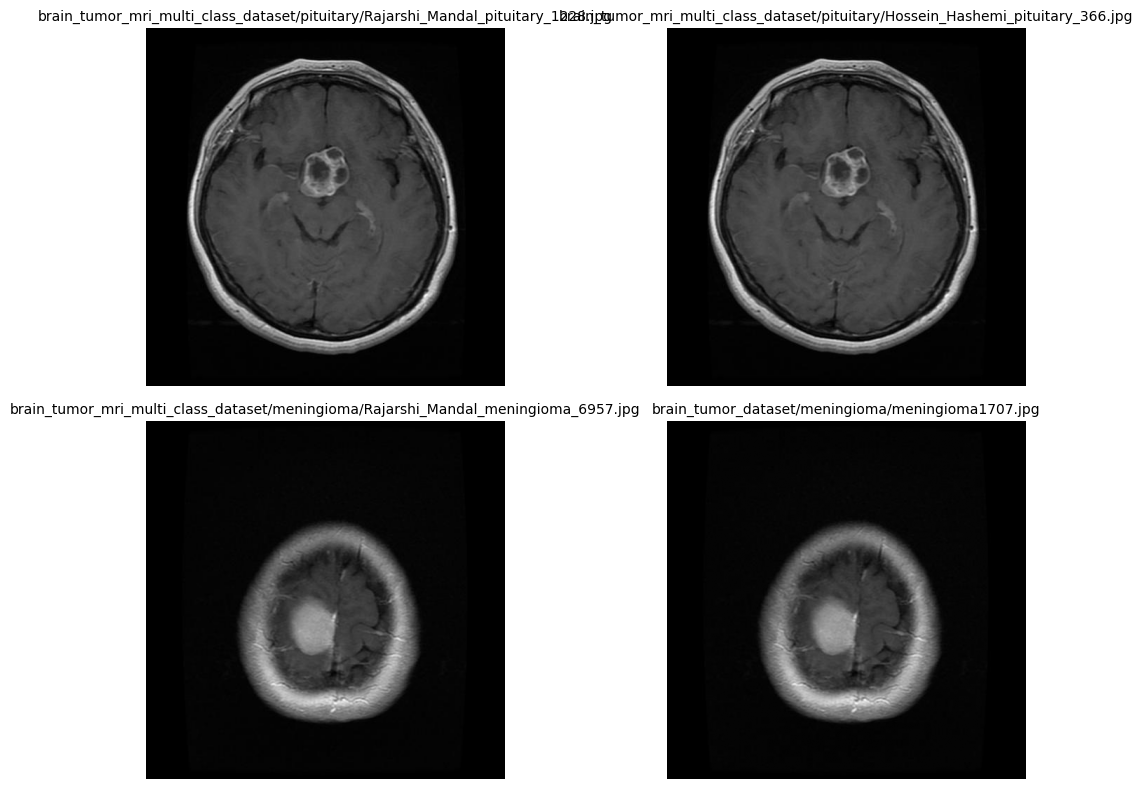

In [4]:
FOLDER_TO_CLASS = {
    'glioma':       'glioma',
    'brain_glioma': 'glioma',
    'meningioma':   'meningioma',
    'brain_menin':  'meningioma',
    'no_tumor':     'notumor',
    'healthy':      'notumor',
    'pituitary':    'pituitary',
}

all_images = glob.glob('./data/**/*.jpg', recursive=True) + \
             glob.glob('./data/**/*.png', recursive=True) + \
             glob.glob('./data/**/*.jpeg', recursive=True)

print(f"Found {len(all_images)} images. Computing hashes in parallel...")

def process_image(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path)).lower()
    target_class = FOLDER_TO_CLASS.get(folder_name)
    if target_class is None:
        return None
    try:
        with Image.open(img_path) as img:
            file_hash = str(imagehash.phash(img))
        return (img_path, target_class, file_hash)
    except Exception as e:
        print(f"Error: {e}")
        return None

results = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(process_image, p): p for p in all_images}
    for future in as_completed(futures):
        result = future.result()
        if result:
            results.append(result)

print(f"Hashing complete. Deduplicating...")

classes_data = {'glioma': [], 'meningioma': [], 'notumor': [], 'pituitary': []}
seen_hashes = set()
hash_to_paths = defaultdict(list)

for img_path, target_class, file_hash in results:
    hash_to_paths[file_hash].append(img_path)
    if file_hash not in seen_hashes:
        classes_data[target_class].append(img_path)
        seen_hashes.add(file_hash)

duplicates = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
print(f"Duplicate sets found: {len(duplicates)}")

if duplicates:
    sample_hashes = random.sample(list(duplicates.keys()), min(2, len(duplicates)))
    fig, axes = plt.subplots(len(sample_hashes), 2, figsize=(12, 4 * len(sample_hashes)))
    if len(sample_hashes) == 1:
        axes = [axes]
    for idx, h in enumerate(sample_hashes):
        for col, path in enumerate(duplicates[h][:2]):
            try:
                axes[idx][col].imshow(Image.open(path), cmap='gray')
                axes[idx][col].set_title("/".join(path.split('/')[-3:]), fontsize=10)
                axes[idx][col].axis('off')
            except Exception:
                axes[idx][col].set_title("Load error")
                axes[idx][col].axis('off')
    plt.tight_layout()
    plt.show()

### Class Distribution (After Deduplication)

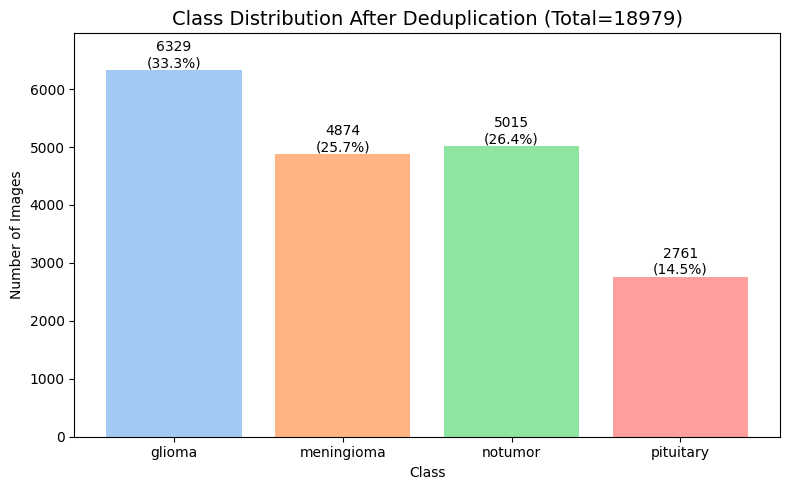

In [5]:
class_counts = {cls: len(paths) for cls, paths in classes_data.items()}
total = sum(class_counts.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(), color=sns.color_palette('pastel'))

for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count}\n({count/total*100:.1f}%)",
            ha='center', va='bottom', fontsize=10)

ax.set_title(f"Class Distribution After Deduplication (Total={total})", fontsize=14)
ax.set_ylabel("Number of Images")
ax.set_xlabel("Class")
ax.margins(y=0.1)
plt.tight_layout()
plt.show()


### Results

The bar chart shows a clear class imbalance: glioma and notumor are the largest classes, while pituitary has noticeably fewer images than the rest. This means we need to take measures to prevent the model from becoming biased toward the majority classes

### Unique Resolutions and Shapes

Total unique resolutions: 459


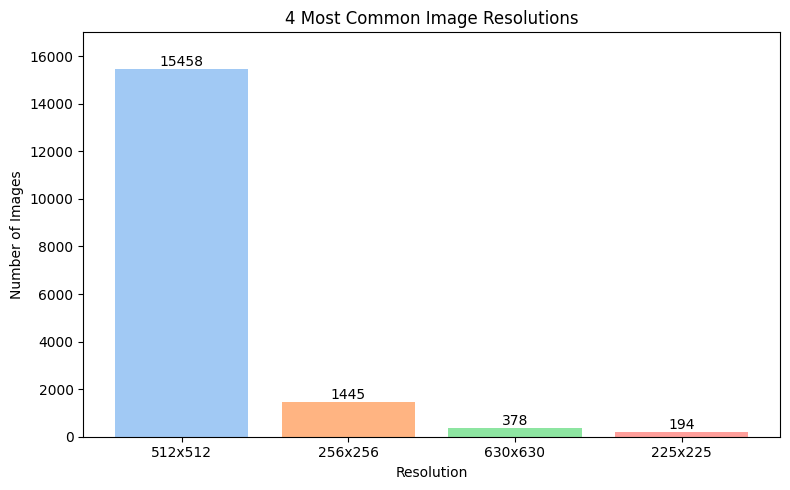

In [6]:
resolutions = []
for class_name, paths in classes_data.items():
    for img_path in paths:
        try:
            with Image.open(img_path) as img:
                resolutions.append(img.size)
        except Exception:
            continue

resolution_counts = Counter(resolutions)
print(f"Total unique resolutions: {len(resolution_counts)}")

top_4 = resolution_counts.most_common(4)
labels = [f"{w}x{h}" for (w, h), count in top_4]
counts = [count for (w, h), count in top_4]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=sns.color_palette('pastel'))

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count}", ha='center', va='bottom', fontsize=10)

ax.set_title("4 Most Common Image Resolutions")
ax.set_xlabel("Resolution")
ax.set_ylabel("Number of Images")
ax.margins(y=0.1)
plt.tight_layout()
plt.show()

### Results

Most of our images fall between 256x256 and 512x512. While 512x512 is the most common resolution, we decided to go with 256x256 first for faster computation and compatibility with transfer-learning networks like DenseNet-121.

## checking the most common color format (RGB, Grayscale...)

In [7]:
modes = []
for class_name, paths in classes_data.items():
    for img_path in paths:
        try:
            with Image.open(img_path) as img:
                modes.append(img.mode)
        except Exception:
            continue

mode_counts = Counter(modes)
print("Top 3 most common color formats:")
for mode, count in mode_counts.most_common(3):
    print(f"  {mode}: {count} images")

Top 3 most common color formats:
  RGB: 11989 images
  L: 4191 images
  RGBA: 2799 images


### Color Mode by Class and Source Dataset

Overall color mode counts:
mode
RGB     11989
L        4191
RGBA     2799
Name: count, dtype: int64 

Color vs grayscale, by class (%):
is_color    False  True 
class                   
glioma        4.8   95.2
meningioma    3.3   96.7
notumor      73.1   26.9
pituitary     2.1   97.9

Color vs grayscale, by source dataset (%):
is_color                             False  True 
source_dataset                                   
brain_cancer_mri_dataset               0.0  100.0
brain_tumor_dataset                    5.8   94.2
brain_tumor_mri_multi_class_dataset   33.9   66.1



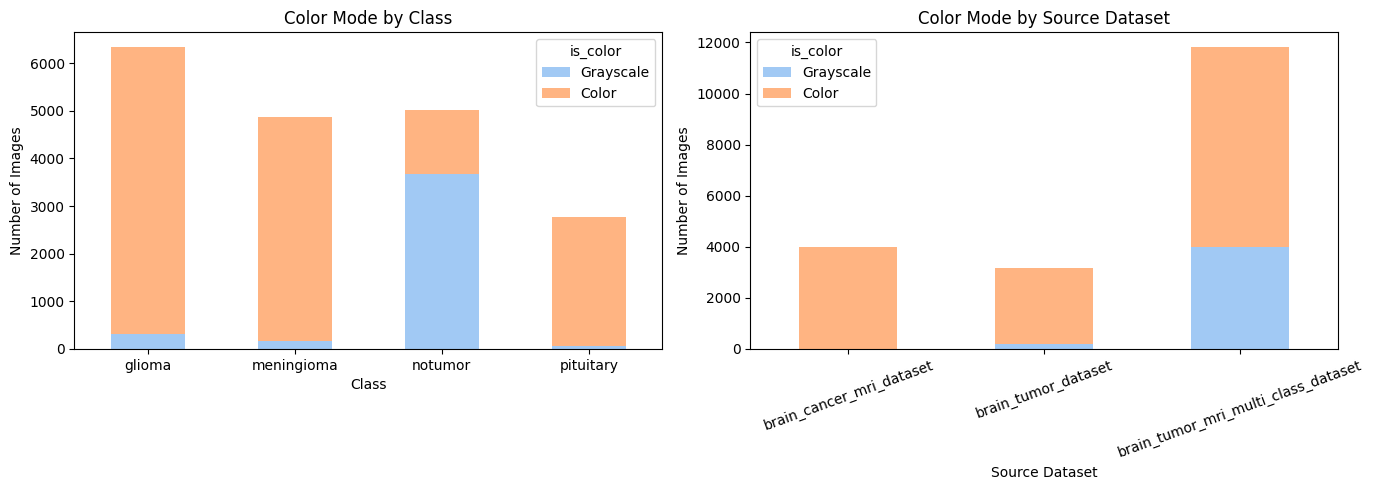

In [8]:
def get_source_dataset(path):
    parts = os.path.normpath(path).split(os.sep)
    try:
        idx = parts.index('data')
        return parts[idx + 1]
    except (ValueError, IndexError):
        return 'unknown'

records = []
for cls, paths in classes_data.items():
    for img_path in paths:
        try:
            with Image.open(img_path) as img:
                mode = img.mode
        except Exception:
            continue
        records.append({
            'class': cls,
            'source_dataset': get_source_dataset(img_path),
            'mode': mode,
            'is_color': mode not in ('L', '1', 'I', 'I;16')
        })

mode_df = pd.DataFrame(records)

print("Overall color mode counts:")
print(mode_df['mode'].value_counts(), "\n")

class_mode_pct = pd.crosstab(mode_df['class'], mode_df['is_color'], normalize='index') * 100
class_mode_pct.columns = ['Grayscale %', 'Color %'] if False in class_mode_pct.columns else class_mode_pct.columns
print("Color vs grayscale, by class (%):")
print(pd.crosstab(mode_df['class'], mode_df['is_color'], normalize='index').mul(100).round(1))
print()

print("Color vs grayscale, by source dataset (%):")
print(pd.crosstab(mode_df['source_dataset'], mode_df['is_color'], normalize='index').mul(100).round(1))
print()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_class = pd.crosstab(mode_df['class'], mode_df['is_color'])
ct_class = ct_class.rename(columns={False: 'Grayscale', True: 'Color'})
ct_class.plot(kind='bar', stacked=True, ax=axes[0], color=sns.color_palette('pastel')[:2])
axes[0].set_title("Color Mode by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis='x', rotation=0)

ct_source = pd.crosstab(mode_df['source_dataset'], mode_df['is_color'])
ct_source = ct_source.rename(columns={False: 'Grayscale', True: 'Color'})
ct_source.plot(kind='bar', stacked=True, ax=axes[1], color=sns.color_palette('pastel')[:2])
axes[1].set_title("Color Mode by Source Dataset")
axes[1].set_xlabel("Source Dataset")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Results

- `notumor` is mostly grayscale, while glioma, meningioma, and pituitary are mostly color.
- Color mode also lines up with source dataset: `brain_cancer_mri_dataset` is 100% color, the multi-class dataset is mostly grayscale, and the third source is a mix.

Since `load_and_preprocess()` converts every image to grayscale before it reaches the model, this doesn't actually bias training — so there's no need to drop any of the color-sourced data.

## Data Splits

There are two data splits used in this notebook, both built in the cell below (which must run before training any model, 1 through 8):

- A **"main" split**, encompassing all classes with their natural imbalance. This split is used by Models 1, 2, 3, 4, 5, 6, and 7.
- A separate **"balanced" split**, created by undersampling the larger classes to match the count of the smallest class (pituitary). This split is exclusively used by Model 8, to test undersampling as an alternative to class weighting.

In [9]:
class_to_label = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
all_paths, all_labels = [], []

for class_name, paths in classes_data.items():
    for p in paths:
        all_paths.append(p)
        all_labels.append(class_to_label[class_name])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# --- Main Data Split (used by Models 1, 2, 3, 4, 5, 6, 7) ---
# Split into training (64%), validation (16%), and test (20%)
X_train_paths_main_temp, X_test_paths_main, y_train_main_temp, y_test_main = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
X_train_paths_main, X_val_paths_main, y_train_main, y_val_main = train_test_split(
    X_train_paths_main_temp, y_train_main_temp, test_size=0.2, random_state=42, stratify=y_train_main_temp
)

print(f"\nMain Split Sizes:")
print(f"  Training set: {len(X_train_paths_main)}")
print(f"  Validation set: {len(X_val_paths_main)}")
print(f"  Test set: {len(X_test_paths_main)}")


# --- Balanced Data Split (used only by Model 8) ---
pituitary_count = len(classes_data['pituitary'])

balanced_paths = []
balanced_labels = []

for class_name, paths in classes_data.items():
    label = class_to_label[class_name]
    random.shuffle(paths) # Shuffle paths to ensure random selection
    sampled_paths = paths[:pituitary_count] # Take a maximum of pituitary_count images
    balanced_paths.extend(sampled_paths)
    balanced_labels.extend([label] * len(sampled_paths))

balanced_paths = np.array(balanced_paths)
balanced_labels = np.array(balanced_labels)

X_train_paths_balanced_temp, X_test_paths_balanced, y_train_balanced_temp, y_test_balanced = train_test_split(
    balanced_paths, balanced_labels, test_size=0.2, random_state=42, stratify=balanced_labels
)
X_train_paths_balanced, X_val_paths_balanced, y_train_balanced, y_val_balanced = train_test_split(
    X_train_paths_balanced_temp, y_train_balanced_temp, test_size=0.2, random_state=42, stratify=y_train_balanced_temp
)

print(f"\nBalanced Split Sizes (for Model 8):")
print(f"  Training set: {len(X_train_paths_balanced)}")
print(f"  Validation set: {len(X_val_paths_balanced)}")
print(f"  Test set: {len(X_test_paths_balanced)}")


Main Split Sizes:
  Training set: 12146
  Validation set: 3037
  Test set: 3796

Balanced Split Sizes (for Model 8):
  Training set: 7068
  Validation set: 1767
  Test set: 2209


## Modeling Overview

### 8 models are trained below, varying architecture (from-scratch CNN vs. DenseNet-121 vs. EfficientNetB0), resolution (256x256 vs. 512x512), and class-imbalance strategy (class weighting vs. undersampling) — see each model's own header for its specific configuration.

### **Note on Model 8:** it doesn't appear in the "Final Model Comparison" table with Models 1-7, because it uses an independently-constructed, undersampled data split (different size and class balance than the shared main split everyone else uses) — comparing its metrics directly wouldn't be a controlled comparison. It's evaluated separately in its own section.

## Model 1: Baseline CNN, Learning Rate 0.0001

This model establishes the baseline for the from-scratch CNN architecture: four convolutional blocks (each followed by Batch Normalization and Max Pooling), a Flatten layer, a 256-neuron Dense layer with Dropout, and a Softmax output. It is trained on the full, naturally imbalanced dataset at 256×256 resolution, using standard class weights (Pituitary weighted 2.0) and the pituitary-specific double-augmentation cycle to address the underrepresentation of that class. The learning rate is set to 0.0001, with an Early Stopping callback (patience 5) monitoring validation loss to prevent overfitting.

In [10]:
# Duplicated in Models 1, 2, and 3 for independence
TARGET_SIZE = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

def augment_pituitary(image, label):
    is_pituitary = tf.equal(tf.argmax(label), 3)
    image = tf.cond(is_pituitary,
                    lambda: augment(image, label)[0],
                    lambda: image)
    return image, label

def make_dataset(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(augment_pituitary, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [11]:
model1 = Sequential()

model1.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))

model1.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))

model1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))

model1.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D((2,2)))
model1.add(Flatten())
model1.add(Dense(256, activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(4, activation='softmax'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,168,260 (65.49 MB)

 Trainable params: 17,167,300 (65.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
#since pituitary have the least amount of photos during in the data, we punish the model more for mistaking it
class_weight_dict_standard = {
    0: 1.0,  # glioma
    1: 1.0,  # meningioma
    2: 1.0,  # notumor
    3: 2.0   # pituitary
}

In [13]:

train_ds1 = make_dataset(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds1 = make_dataset(X_val_paths_main, y_val_main, shuffle=False)
test_ds1 = make_dataset(X_test_paths_main, y_test_main, shuffle=False)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model1.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time1 = time.time()
history1 = model1.fit(train_ds1, epochs=30, validation_data=validation_ds1,class_weight=class_weight_dict_standard,callbacks=[early_stop])
end_time1 = time.time()
training_time1 = (end_time1 - start_time1) / 60  # Convert to minutes
print(f"Model 1 training time: {training_time1:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 67s 138ms/step - accuracy: 0.6344 - loss: 1.1056 - val_accuracy: 0.4356 - val_loss: 2.4376
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - accuracy: 0.7435 - loss: 0.6520 - val_accuracy: 0.8541 - val_loss: 0.3829
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.8007 - loss: 0.5196 - val_accuracy: 0.8811 - val_loss: 0.3189
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 122ms/step - accuracy: 0.8460 - loss: 0.4051 - val_accuracy: 0.8601 - val_loss: 0.3394
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.8543 - loss: 0.3728 - val_accuracy: 0.9068 - val_loss: 0.2323
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 122ms/step - accuracy: 0.8818 - loss: 0.3098 - val_accuracy: 0.9121 - val_loss: 0.2277
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accuracy: 0.9014 - loss: 0.2622 - val_accuracy: 0.9266 - val_loss: 0.1916
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 44s 114ms/step - accuracy: 0.9106 - loss: 0

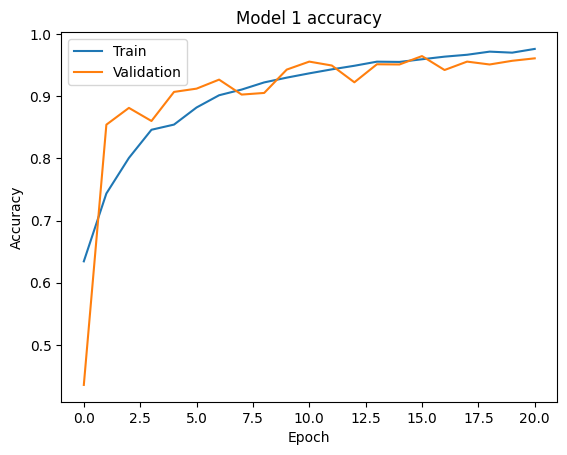

In [14]:

# Plot training & validation accuracy values
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model 1 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

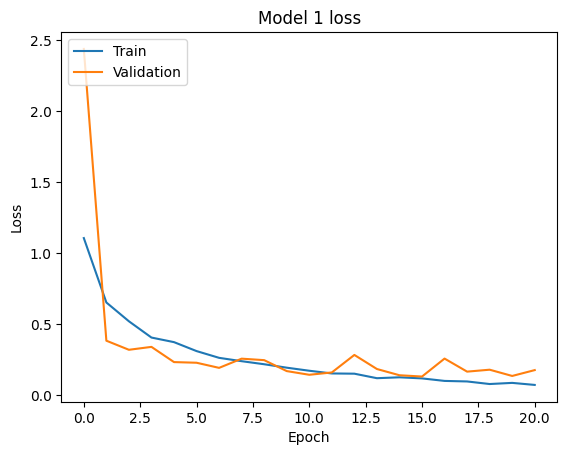

In [15]:

#plotting train & validation loss
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model 1 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [16]:
val_predictions1 = model1.predict(validation_ds1)
val_predicted_classes1 = np.argmax(val_predictions1, axis=1)
val_true_classes1 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds1])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes1, val_predicted_classes1, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.96      0.96      1013
  meningioma       0.95      0.93      0.94       780
     notumor       0.97      0.99      0.98       802
   pituitary       0.98      0.99      0.99       442

    accuracy                           0.96      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.96      0.96      0.96      3037



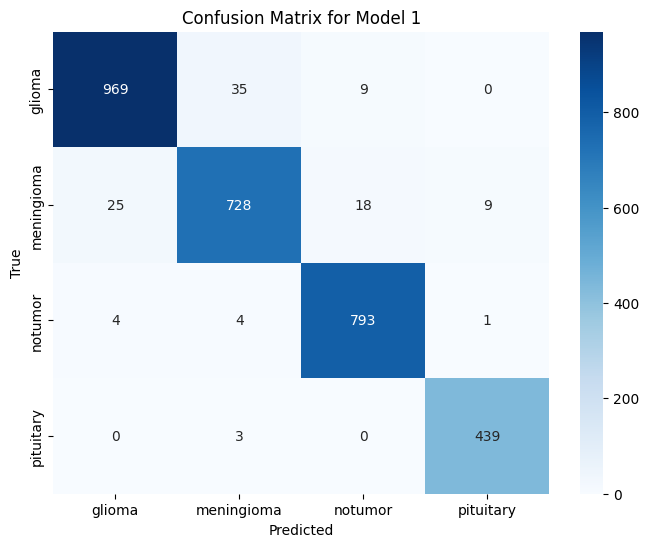

In [17]:
cm1 = confusion_matrix(val_true_classes1, val_predicted_classes1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 1')
plt.show()

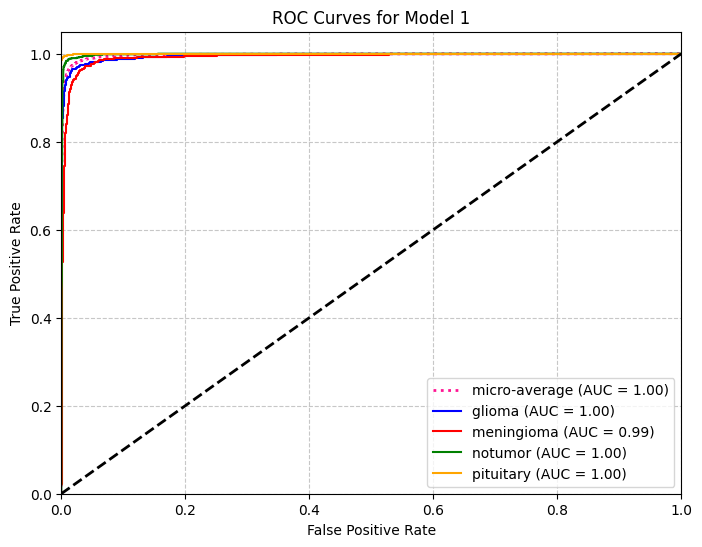

In [18]:
# Model 1 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 1 (using val_true_classes from previous cells)
y_true = val_true_classes1
y_pred_proba = val_predictions1

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 1')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 2: Lower Learning Rate and Stricter Early Stopping

During initial testing of Model 1, minor instabilities were observed in the validation accuracy curve. Model 2 reuses the identical baseline CNN architecture, class weights, and pituitary double-augmentation strategy, but tests whether a more granular convergence improves generalization by reducing the learning rate to 0.00005 and tightening the Early Stopping patience to 3 epochs.

In [19]:
# Duplicated in Models 1, 2, and 3 for independence
TARGET_SIZE = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

def augment_pituitary(image, label):
    is_pituitary = tf.equal(tf.argmax(label), 3)
    image = tf.cond(is_pituitary,
                    lambda: augment(image, label)[0],
                    lambda: image)
    return image, label

def make_dataset(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(augment_pituitary, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [20]:
model2 = Sequential()

model2.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))

model2.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))

model2.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))

model2.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D((2,2)))
model2.add(Flatten())
model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(4, activation='softmax'))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,168,260 (65.49 MB)

 Trainable params: 17,167,300 (65.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
train_ds2 = make_dataset(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds2 = make_dataset(X_val_paths_main, y_val_main, shuffle=False)
test_ds2 = make_dataset(X_test_paths_main, y_test_main, shuffle=False)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
model2.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

start_time2 = time.time()
history2 = model2.fit(train_ds2, epochs=30, validation_data=validation_ds2,class_weight=class_weight_dict_standard,callbacks=[early_stop])
end_time2 = time.time()
training_time2 = (end_time2 - start_time2) / 60  # Convert to minutes
print(f"Model 2 training time: {training_time2:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 55s 125ms/step - accuracy: 0.6537 - loss: 1.0116 - val_accuracy: 0.3790 - val_loss: 3.7261
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 110ms/step - accuracy: 0.7552 - loss: 0.6233 - val_accuracy: 0.8196 - val_loss: 0.4120
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.8122 - loss: 0.4960 - val_accuracy: 0.8597 - val_loss: 0.3381
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.8419 - loss: 0.4099 - val_accuracy: 0.8946 - val_loss: 0.2711
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.8688 - loss: 0.3448 - val_accuracy: 0.9078 - val_loss: 0.2406
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.8933 - loss: 0.2844 - val_accuracy: 0.9193 - val_loss: 0.2035
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.9083 - loss: 0.2506 - val_accuracy: 0.9095 - val_loss: 0.2480
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.9174 - loss: 0

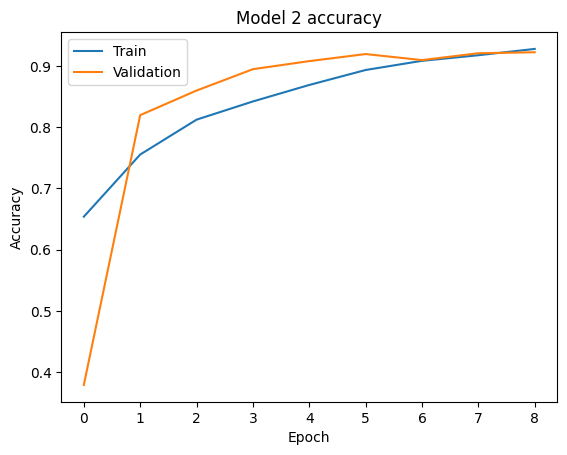

In [22]:

# Plot training & validation accuracy values
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model 2 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

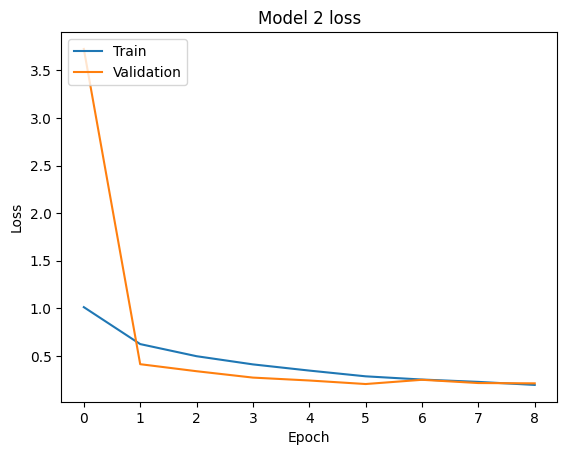

In [23]:

#plotting train & validation loss
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model 2 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [24]:
val_predictions2 = model2.predict(validation_ds2)
val_predicted_classes2 = np.argmax(val_predictions2, axis=1)
val_true_classes2 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds2])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes2, val_predicted_classes2, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step
              precision    recall  f1-score   support

      glioma       0.92      0.89      0.91      1013
  meningioma       0.84      0.89      0.86       780
     notumor       0.96      0.95      0.96       802
   pituitary       0.98      0.98      0.98       442

    accuracy                           0.92      3037
   macro avg       0.93      0.93      0.93      3037
weighted avg       0.92      0.92      0.92      3037



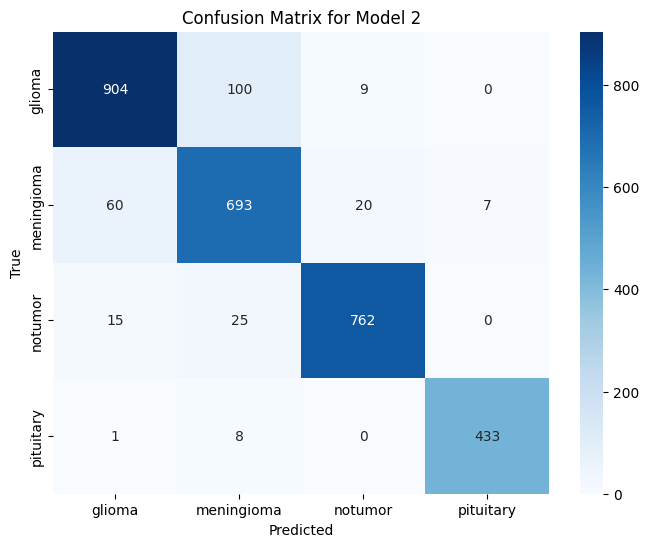

In [25]:
cm2 = confusion_matrix(val_true_classes2, val_predicted_classes2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 2')
plt.show()

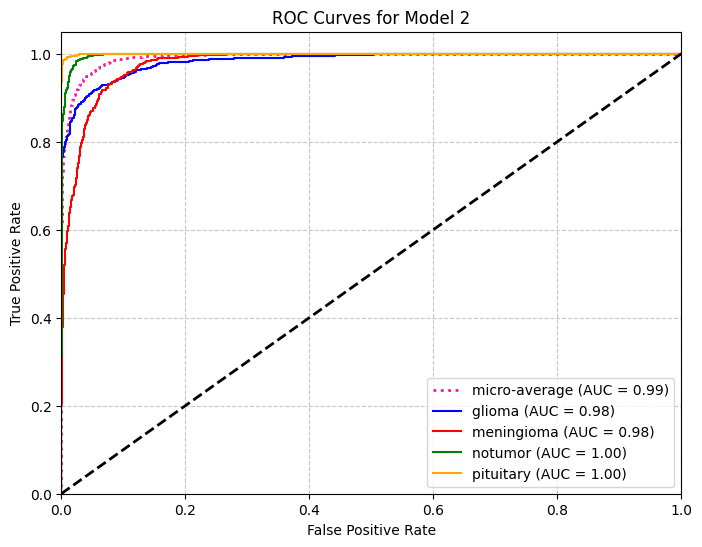

In [26]:
# Model 2 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 2 (using val_true_classes from previous cells)
y_true = val_true_classes2
y_pred_proba = val_predictions2

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 2')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 3: Extending Class Weighting to Meningioma

Model 3 reuses the same baseline CNN architecture as Models 1 and 2, with the learning rate returned to 0.0001 and Early Stopping patience of 5, matching Model 1's configuration. It tests an alternative class-weighting strategy: in addition to the existing 2.0 weight multiplier for Pituitary, Meningioma is assigned a 1.5 weight multiplier, based on the hypothesis that its more heterogeneous visual presentation may also benefit from increased training emphasis.

In [27]:
# Duplicated in Models 1, 2, and 3 for independence
TARGET_SIZE = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

def augment_pituitary(image, label):
    is_pituitary = tf.equal(tf.argmax(label), 3)
    image = tf.cond(is_pituitary,
                    lambda: augment(image, label)[0],
                    lambda: image)
    return image, label

def make_dataset(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(augment_pituitary, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [28]:
#since pituitary have the least amount of photos during in the data, we punish the model more for mistaking it
class_weight_dict_model3 = {
    0: 1.0,  # glioma
    1: 1.5,  # meningioma
    2: 1.0,  # notumor
    3: 2.0   # pituitary
}

In [29]:
model3 = Sequential()

model3.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))

model3.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))

model3.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))

model3.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D((2,2)))
model3.add(Flatten())
model3.add(Dense(256, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(4, activation='softmax'))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,168,260 (65.49 MB)

 Trainable params: 17,167,300 (65.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [30]:
train_ds3 = make_dataset(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds3 = make_dataset(X_val_paths_main, y_val_main, shuffle=False)
test_ds3 = make_dataset(X_test_paths_main, y_test_main, shuffle=False)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model3.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time3 = time.time()
history3 = model3.fit(train_ds3, epochs=30, validation_data=validation_ds3,class_weight=class_weight_dict_model3,callbacks=[early_stop])
end_time3 = time.time()
training_time3 = (end_time3 - start_time3) / 60  # Convert to minutes
print(f"Model 3 training time: {training_time3:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 59s 134ms/step - accuracy: 0.6186 - loss: 1.3066 - val_accuracy: 0.3997 - val_loss: 5.8318
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accuracy: 0.7410 - loss: 0.7894 - val_accuracy: 0.8367 - val_loss: 0.4059
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.8055 - loss: 0.5901 - val_accuracy: 0.8874 - val_loss: 0.3112
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.8418 - loss: 0.4856 - val_accuracy: 0.7129 - val_loss: 0.5723
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 43s 113ms/step - accuracy: 0.8675 - loss: 0.4091 - val_accuracy: 0.8597 - val_loss: 0.3337
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 46s 121ms/step - accuracy: 0.8821 - loss: 0.3480 - val_accuracy: 0.9104 - val_loss: 0.2246
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.8980 - loss: 0.3150 - val_accuracy: 0.8722 - val_loss: 0.2861
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.9159 - loss: 0

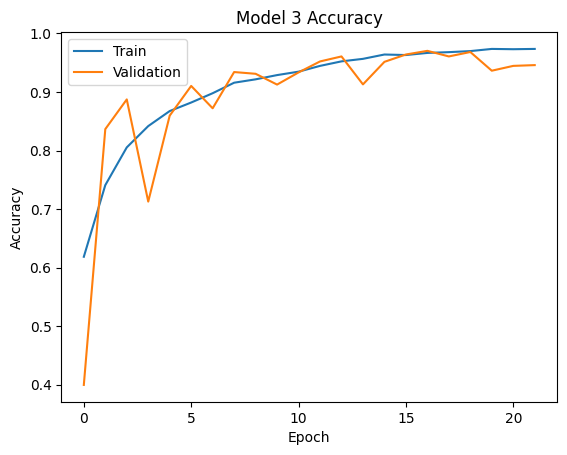

In [31]:

# Plot training & validation accuracy values
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model 3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

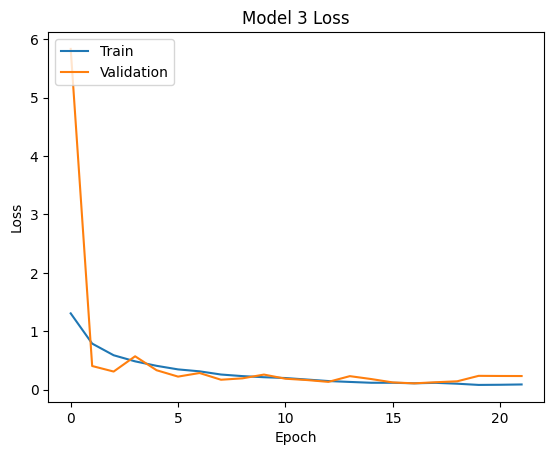

In [32]:

#plotting train & validation loss
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model 3 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [33]:
val_predictions3 = model3.predict(validation_ds3)
val_predicted_classes3 = np.argmax(val_predictions3, axis=1)
val_true_classes3 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds3])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes3, val_predicted_classes3, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.96      0.97      1013
  meningioma       0.94      0.96      0.95       780
     notumor       0.97      0.99      0.98       802
   pituitary       1.00      1.00      1.00       442

    accuracy                           0.97      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.97      0.97      0.97      3037



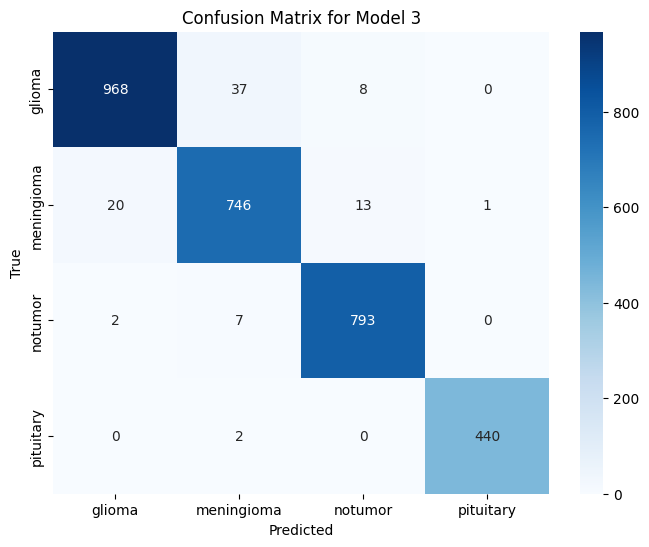

In [34]:
cm3 = confusion_matrix(val_true_classes3, val_predicted_classes3) # Corrected variable name
plt.figure(figsize=(8, 6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 3')
plt.show()

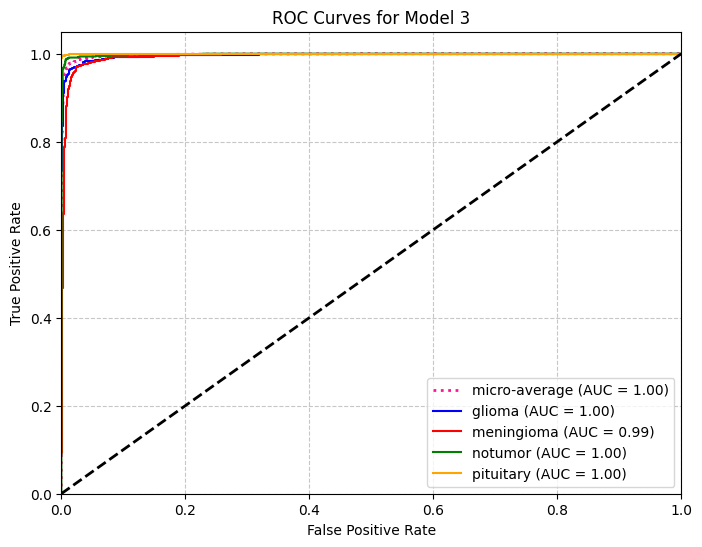

In [35]:
# Model 3 ROC/AUC
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 3 (using val_true_classes from previous cells)
y_true = val_true_classes3
y_pred_proba = val_predictions3

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 3')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 4: DenseNet-121 (Frozen) on Full Dataset with Class Weights, without Pituitary-Specific Augmentation

This model uses the DenseNet-121 architecture, pre-trained on ImageNet, as a frozen feature extractor, with only a custom classification head trained on top. It is trained on the full (naturally imbalanced) dataset with the same class weights used elsewhere (Pituitary weighted 2.0) to compensate for the minority class. Unlike Models 1–3, the pituitary-specific double-augmentation cycle is omitted here — a single, uniform augmentation policy is applied equally across all classes instead, to isolate the effect of the architecture change from the effect of the augmentation strategy.

Since DenseNet-121 expects 3-channel (RGB) input, the single-channel grayscale images are replicated across 3 channels during preprocessing.

In [36]:
# Duplicated in Models 4 and 5 for independence
def load_and_preprocess_densenet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False) # Decode as 1 channel initially
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.concat([img, img, img], axis=-1) # Replicate channel for 3D input
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label


def make_dataset_for_densenet(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_densenet, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [37]:
train_ds4 = make_dataset_for_densenet(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds4 = make_dataset_for_densenet(X_val_paths_main, y_val_main, shuffle=False)
test_ds4 = make_dataset_for_densenet(X_test_paths_main, y_test_main, shuffle=False)

print(f"Training set size for Model 4: {len(X_train_paths_main)}")
print(f"Validation set size for Model 4: {len(X_val_paths_main)}")
print(f"Test set size for Model 4: {len(X_test_paths_main)}")


Training set size for Model 4: 12146
Validation set size for Model 4: 3037
Test set size for Model 4: 3796


In [38]:
baseline_densenet = tf.keras.applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3))

for layer in baseline_densenet.layers:
    layer.trainable = False

model4 = Sequential([
    baseline_densenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model4.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [39]:
early_stop_model4 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model4.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time4 = time.time()
history4 = model4.fit(train_ds4, epochs=30, validation_data=validation_ds4, callbacks=[early_stop_model4], class_weight=class_weight_dict_standard)
end_time4 = time.time()
training_time4 = (end_time4 - start_time4) / 60  # Convert to minutes
print(f"Model 4 training time: {training_time4:.3f} minutes")

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 138s 269ms/step - accuracy: 0.6570 - loss: 0.9700 - val_accuracy: 0.8186 - val_loss: 0.5011
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 59s 155ms/step - accuracy: 0.7987 - loss: 0.5899 - val_accuracy: 0.8538 - val_loss: 0.4006
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 69s 182ms/step - accuracy: 0.8322 - loss: 0.4901 - val_accuracy: 0.8686 - val_loss: 0.3591
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 59s 155ms/step - accuracy: 0.8496 - loss: 0.4319 - val_accuracy: 0.8798 - val_loss: 0.3245
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 60s 157ms/step - accuracy: 0.8635 - loss: 0.3987 - val_accuracy: 0.8808 - val_loss: 0.3067
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 59s 154ms/step - accuracy: 0.8746 - loss: 0.3669 - val_accuracy: 0.8913 - val_loss: 0.2863
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 83s 157ms/step - accuracy: 0.8819 - loss: 0.3461 - val_accuracy: 0.8946 - val_loss: 0.2730
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 82s 156ms/step - accuracy: 0.8837 - loss: 

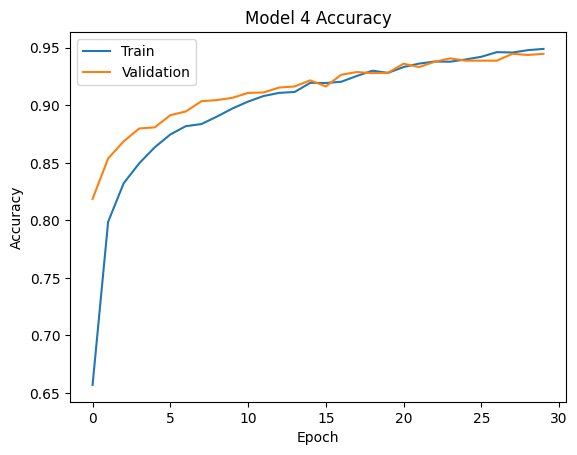

In [40]:
# Plot training & validation accuracy values
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.title('Model 4 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

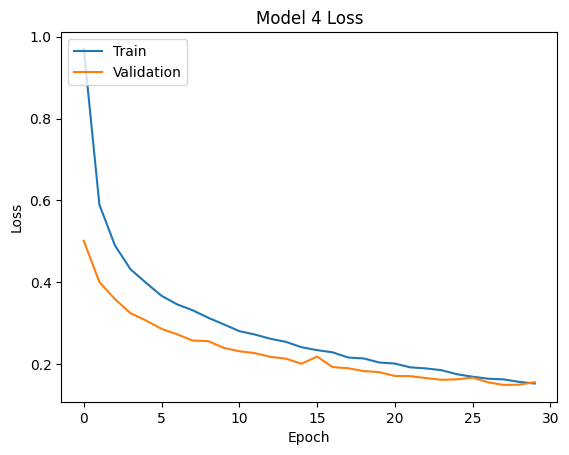

In [41]:
# Plotting train & validation loss
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('Model 4 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [42]:
val_predictions4 = model4.predict(validation_ds4)
val_predicted_classes4 = np.argmax(val_predictions4, axis=1)
val_true_classes4 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds4])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes4, val_predicted_classes4, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 251ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.91      0.94      1013
  meningioma       0.89      0.93      0.91       780
     notumor       0.96      0.98      0.97       802
   pituitary       0.97      0.97      0.97       442

    accuracy                           0.94      3037
   macro avg       0.95      0.95      0.95      3037
weighted avg       0.95      0.94      0.94      3037



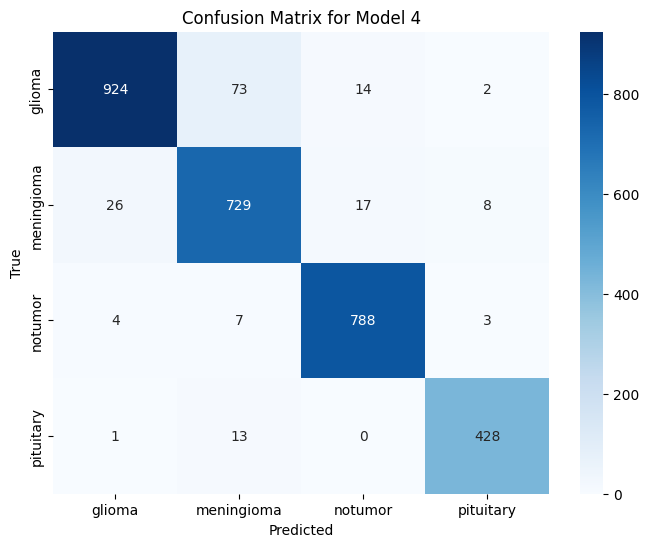

In [43]:
cm4 = confusion_matrix(val_true_classes4, val_predicted_classes4)
plt.figure(figsize=(8, 6))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 4')
plt.show()

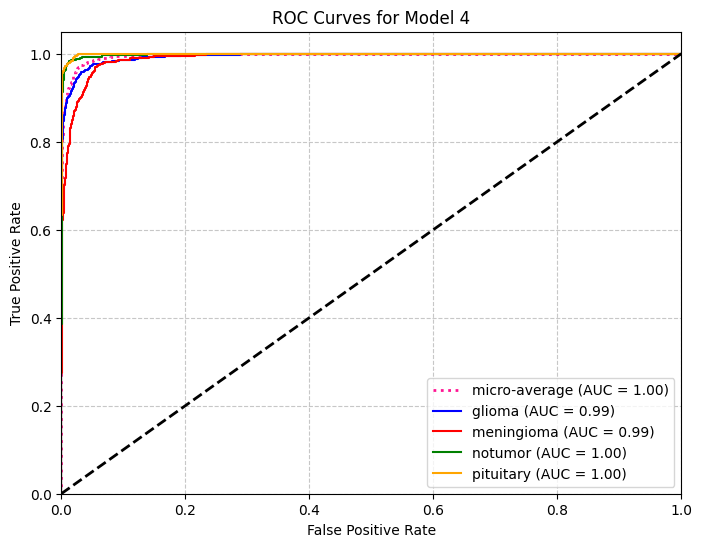

In [44]:
# Model 4 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 4
y_true = val_true_classes4
y_pred_proba = val_predictions4

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 4')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 5: Fine-Tuning the Last 50 DenseNet-121 Layers

This model extends Model 4 by unfreezing the final 50 layers of the DenseNet-121 base, allowing the network to fine-tune its deepest, most task-specific convolutional filters on the MRI dataset, while keeping the earlier, more general-purpose layers frozen. To avoid catastrophic forgetting of the pre-trained representations during fine-tuning, the learning rate is substantially reduced to 0.00001 (compared to Model 4's 0.0001). The classification head architecture is otherwise identical to Model 4.

Model 5 uses the same DenseNet-style preprocessing as Model 4


In [45]:
# Duplicated in Models 4 and 5 for independence
def load_and_preprocess_densenet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False) # Decode as 1 channel initially
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.concat([img, img, img], axis=-1) # Replicate channel for 3D input
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label


def make_dataset_for_densenet(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_densenet, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


In [46]:

train_ds5 = make_dataset_for_densenet(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds5 = make_dataset_for_densenet(X_val_paths_main, y_val_main, shuffle=False)
test_ds5 = make_dataset_for_densenet(X_test_paths_main, y_test_main, shuffle=False)

densenet_ft = DenseNet121(weights='imagenet', include_top=False, input_shape=(256,256,3))
for layer in densenet_ft.layers[:-50]:
    layer.trainable = False

model5 = Sequential([
    densenet_ft,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 1,339,076 (5.11 MB)

 Non-trainable params: 5,961,856 (22.74 MB)

In [47]:
model5.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_model5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_time5 = time.time()
history5 = model5.fit(
    train_ds5,
    validation_data=validation_ds5,
    epochs=20,
    callbacks=[early_stop_model5],
    class_weight=class_weight_dict_standard
)
end_time5 = time.time()
training_time5 = (end_time5 - start_time5) / 60  # Convert to minutes
print(f"Model 5 training time: {training_time5:.3f} minutes")

Epoch 1/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 141s 265ms/step - accuracy: 0.5138 - loss: 1.3600 - val_accuracy: 0.7942 - val_loss: 0.6032
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.7379 - loss: 0.7711 - val_accuracy: 0.8525 - val_loss: 0.4253
Epoch 3/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 60s 157ms/step - accuracy: 0.8052 - loss: 0.5736 - val_accuracy: 0.8689 - val_loss: 0.3461
Epoch 4/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 72s 189ms/step - accuracy: 0.8390 - loss: 0.4741 - val_accuracy: 0.8844 - val_loss: 0.3002
Epoch 5/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 70s 184ms/step - accuracy: 0.8592 - loss: 0.4111 - val_accuracy: 0.8959 - val_loss: 0.2665
Epoch 6/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 70s 185ms/step - accuracy: 0.8767 - loss: 0.3598 - val_accuracy: 0.9045 - val_loss: 0.2375
Epoch 7/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 60s 158ms/step - accuracy: 0.8889 - loss: 0.3273 - val_accuracy: 0.9164 - val_loss: 0.2171
Epoch 8/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 61s 159ms/step - accuracy: 0.8958 - loss: 

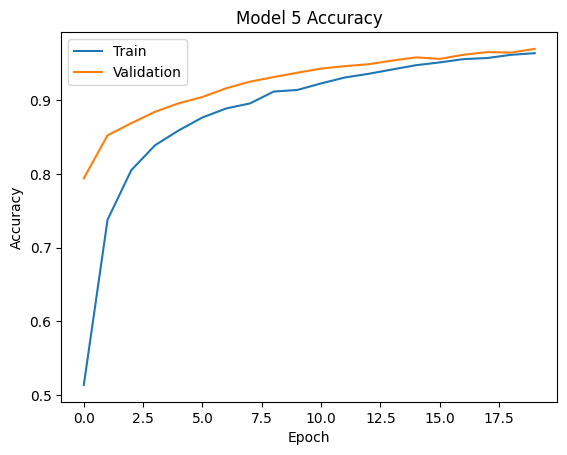

In [48]:
# Plot training & validation accuracy values
plt.plot(history5.history['accuracy'])
plt.plot(history5.history['val_accuracy'])
plt.title('Model 5 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

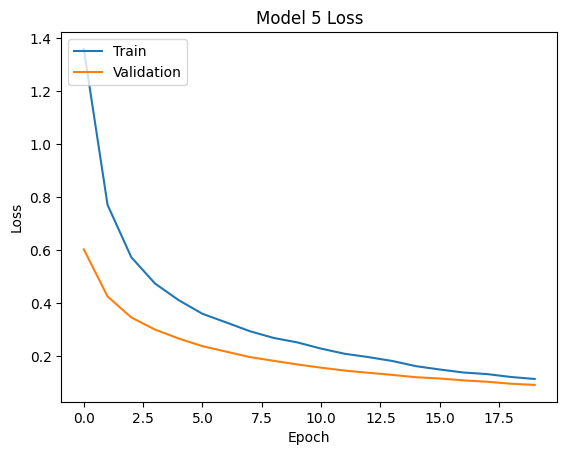

In [49]:
# Plotting train & validation loss
plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.title('Model 5 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [50]:
val_predictions5 = model5.predict(validation_ds5)
val_predicted_classes5 = np.argmax(val_predictions5, axis=1)
val_true_classes5 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds5])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes5, val_predicted_classes5, target_names=class_names))

95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 254ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.97      0.97      1013
  meningioma       0.96      0.95      0.95       780
     notumor       0.98      0.99      0.98       802
   pituitary       0.98      0.98      0.98       442

    accuracy                           0.97      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.97      0.97      0.97      3037



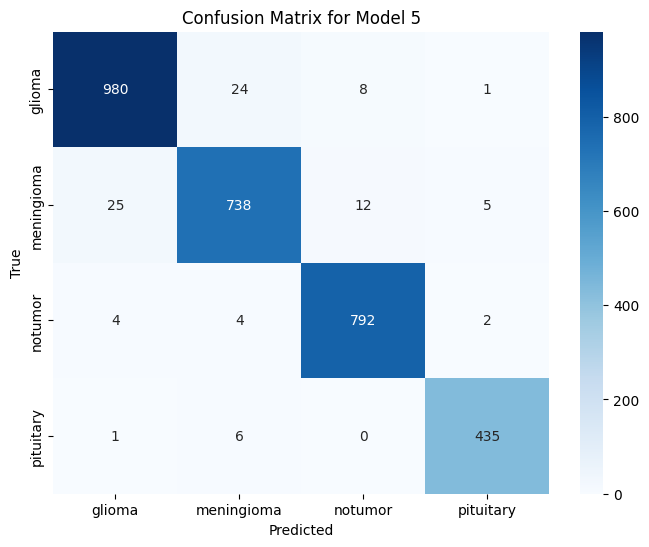

In [51]:
cm5 = confusion_matrix(val_true_classes5, val_predicted_classes5)
plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 5')
plt.show()

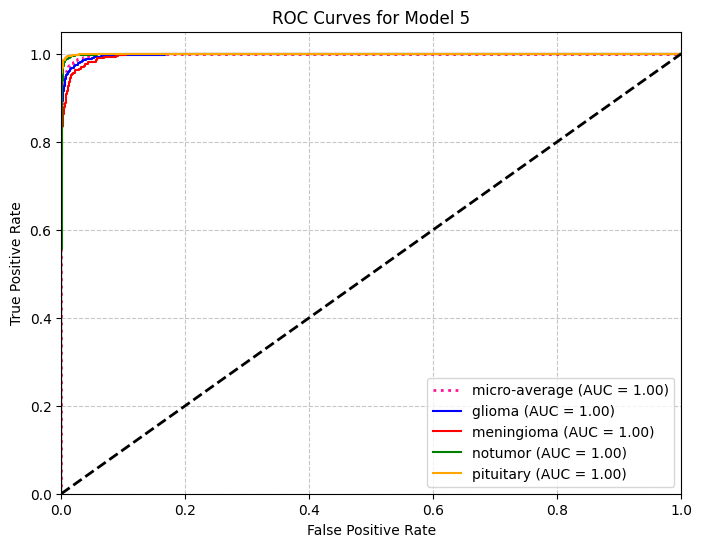

In [52]:
# Model 5 ROC/AUC

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 5
y_true = val_true_classes5
y_pred_proba = val_predictions5

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 5')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 6: Custom CNN at 512x512 Resolution

This model tests whether a higher input resolution of 512x512 improves the performance of a from-scratch CNN compared to the earlier 256x256 models. Given the increased resolution, the batch size is reduced to prevent out-of-memory errors. This resolution was chosen because 512x512 was the most common image resolution found in the dataset.

**Run the cell below first if you want to train Model 6.** This section is fully self-contained -- it defines its own 512x512 preprocessing/`make_dataset_512()` and builds its own datasets, so besides the main split at the top of the notebook, it doesn't require any other model's cells to have run.


In [53]:
TARGET_SIZE_512 = (512, 512)
BATCH_SIZE_512 = 8

def load_and_preprocess_512(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE_512)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset_512(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_512, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.map(augment_pituitary, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_512).prefetch(AUTOTUNE)
    return ds

train_ds6 = make_dataset_512(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds6 = make_dataset_512(X_val_paths_main, y_val_main, shuffle=False)
test_ds6 = make_dataset_512(X_test_paths_main, y_test_main, shuffle=False)

In [54]:
model6 = Sequential()

model6.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(TARGET_SIZE_512[0], TARGET_SIZE_512[1], 1)))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model6.add(BatchNormalization())
model6.add(MaxPooling2D((2,2)))

model6.add(GlobalAveragePooling2D())
model6.add(Dense(256, activation='relu'))
model6.add(Dropout(0.5))
model6.add(Dense(NUM_CLASSES, activation='softmax'))

model6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,324 (6.50 MB)

 Trainable params: 1,702,340 (6.49 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [55]:


early_stop_model6 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_model6 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model6.compile(
    optimizer=Adam(learning_rate=0.00005, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time6 = time.time()
history6 = model6.fit(
    train_ds6,
    epochs=30,
    validation_data=validation_ds6,
    class_weight=class_weight_dict_standard,
    callbacks=[early_stop_model6, reduce_lr_model6]
)
end_time6 = time.time()
training_time6 = (end_time6 - start_time6) / 60
print(f"Model 6 training time: {training_time6:.3f} minutes")

Epoch 1/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 207s 122ms/step - accuracy: 0.6050 - loss: 1.0692 - val_accuracy: 0.7060 - val_loss: 0.7850 - learning_rate: 5.0000e-05
Epoch 2/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 165s 109ms/step - accuracy: 0.7172 - loss: 0.8080 - val_accuracy: 0.7010 - val_loss: 0.7242 - learning_rate: 5.0000e-05
Epoch 3/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 165s 108ms/step - accuracy: 0.7676 - loss: 0.6754 - val_accuracy: 0.8410 - val_loss: 0.4135 - learning_rate: 5.0000e-05
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 166s 109ms/step - accuracy: 0.8003 - loss: 0.5786 - val_accuracy: 0.8284 - val_loss: 0.4554 - learning_rate: 5.0000e-05
Epoch 5/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 164s 108ms/step - accuracy: 0.8190 - loss: 0.5162 - val_accuracy: 0.7422 - val_loss: 0.6270 - learning_rate: 5.0000e-05
Epoch 6/30
1518/1519 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8332 - loss: 0.4872
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1519/1519 ━━━━━━━━━━━━━━

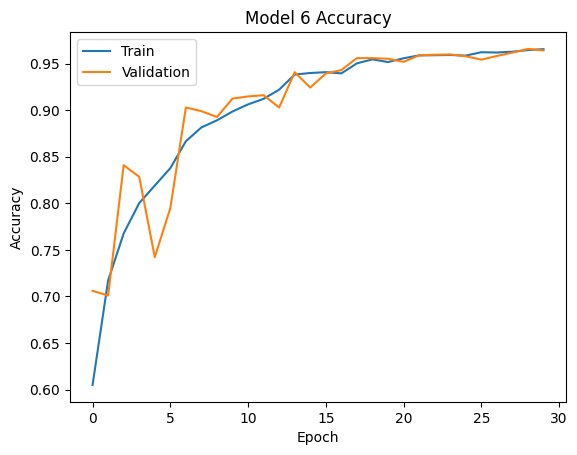

In [56]:
# Plot training & validation accuracy values
plt.plot(history6.history['accuracy'])
plt.plot(history6.history['val_accuracy'])
plt.title('Model 6 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

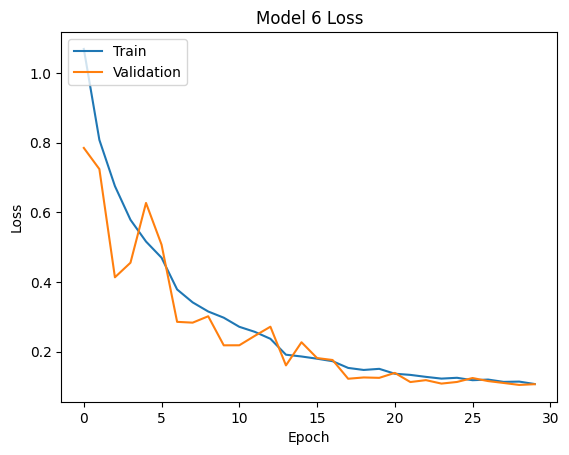

In [57]:
# Plotting train & validation loss
plt.plot(history6.history['loss'])
plt.plot(history6.history['val_loss'])
plt.title('Model 6 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [58]:
val_predictions6 = model6.predict(validation_ds6)
val_predicted_classes6 = np.argmax(val_predictions6, axis=1)
val_true_classes6 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds6])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes6, val_predicted_classes6, target_names=class_names))

380/380 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.97      0.97      1013
  meningioma       0.95      0.94      0.94       780
     notumor       0.97      0.99      0.98       802
   pituitary       0.98      0.98      0.98       442

    accuracy                           0.97      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.97      0.97      0.97      3037



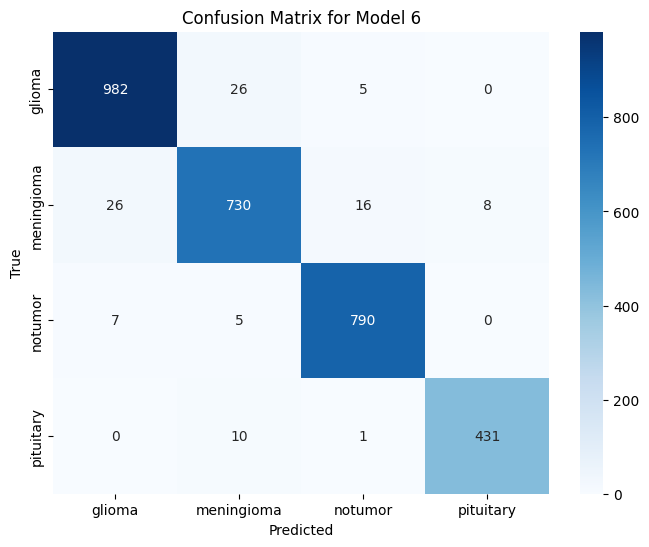

In [59]:
cm6 = confusion_matrix(val_true_classes6, val_predicted_classes6)
plt.figure(figsize=(8, 6))
sns.heatmap(cm6, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 6')
plt.show()

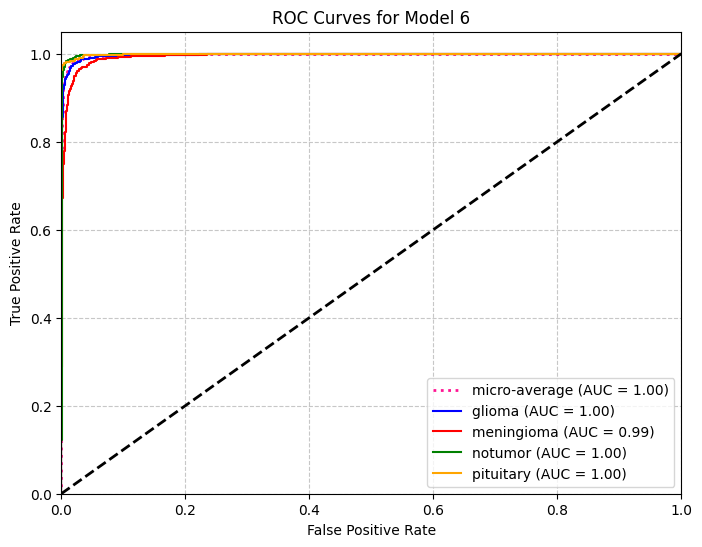

In [60]:
# Model 6 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 6
y_true = val_true_classes6
y_pred_proba = val_predictions6

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 6')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Model 7: EfficientNetB0 Transfer Learning at 512x512

This model tests whether increasing the input resolution to 512x512 also benefits transfer learning performance -- serving as a counterpart to Model 6 (same 512x512 resolution, but a from-scratch CNN) and to Models 4/5 (DenseNet-121 transfer learning, but at 256x256). It uses the same main data split as every other model, but applies EfficientNet-specific preprocessing (3-channel conversion via `tf.image.grayscale_to_rgb` and the built-in `preprocess_input`), which matches the normalization scheme EfficientNet's pre-trained weights expect -- unlike the from-scratch models' simpler manual /255 normalization.

**Run the cell below first if you want to train Model 7.** This section is fully self-contained -- it defines its own `TARGET_SIZE_512`/`BATCH_SIZE_512` and `make_dataset_efficientnet_512()` and builds its own datasets, so besides the main split at the top of the notebook, it doesn't require Model 6's (or any other model's) cells to have run.


In [61]:
# Defined independently so Model 7 can run without requiring Model 6's cells to have been executed first.

TARGET_SIZE_512 = (512, 512)
BATCH_SIZE_512 = 8

def load_and_preprocess_efficientnet_512(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False) # Decode as 1 channel
    img = tf.image.grayscale_to_rgb(img) # Convert to 3 channels for EfficientNet
    img = tf.image.resize(img, TARGET_SIZE_512)
    img = preprocess_input(img) # EfficientNet specific preprocessing
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset_efficientnet_512(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess_efficientnet_512, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_512).prefetch(AUTOTUNE)
    return ds


train_ds7 = make_dataset_efficientnet_512(X_train_paths_main, y_train_main, shuffle=True, augment_data=True)
validation_ds7 = make_dataset_efficientnet_512(X_val_paths_main, y_val_main, shuffle=False)
test_ds7 = make_dataset_efficientnet_512(X_test_paths_main, y_test_main, shuffle=False)

print(f"Training set size for Model 7: {len(X_train_paths_main)}")
print(f"Validation set size for Model 7: {len(X_val_paths_main)}")

Training set size for Model 7: 12146
Validation set size for Model 7: 3037


In [62]:

baseline_efficientnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(TARGET_SIZE_512[0], TARGET_SIZE_512[1], 3))

# Freeze the layers of the pre-trained model
for layer in baseline_efficientnet.layers:
    layer.trainable = False

# Create Model 7
model7 = Sequential([
    baseline_efficientnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model7.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 16, 16, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [63]:
early_stop_model7 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model7.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time7 = time.time()
history7 = model7.fit(
    train_ds7,
    epochs=30,
    validation_data=validation_ds7,
    class_weight=class_weight_dict_standard,
    callbacks=[early_stop_model7]
)
end_time7 = time.time()

training_time7 = (end_time7 - start_time7) / 60 # Convert to minutes
print(f"Model 7 training time: {training_time7:.3f} minutes")

Epoch 1/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 172s 91ms/step - accuracy: 0.7876 - loss: 0.6227 - val_accuracy: 0.8795 - val_loss: 0.3326
Epoch 2/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 136s 63ms/step - accuracy: 0.8654 - loss: 0.3820 - val_accuracy: 0.9039 - val_loss: 0.2563
Epoch 3/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 99s 65ms/step - accuracy: 0.8815 - loss: 0.3289 - val_accuracy: 0.9141 - val_loss: 0.2249
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 96s 63ms/step - accuracy: 0.8959 - loss: 0.2877 - val_accuracy: 0.9246 - val_loss: 0.1976
Epoch 5/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 145s 65ms/step - accuracy: 0.9081 - loss: 0.2592 - val_accuracy: 0.9236 - val_loss: 0.1942
Epoch 6/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 95s 63ms/step - accuracy: 0.9162 - loss: 0.2383 - val_accuracy: 0.9384 - val_loss: 0.1629
Epoch 7/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 98s 64ms/step - accuracy: 0.9190 - loss: 0.2222 - val_accuracy: 0.9397 - val_loss: 0.1650
Epoch 8/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.92

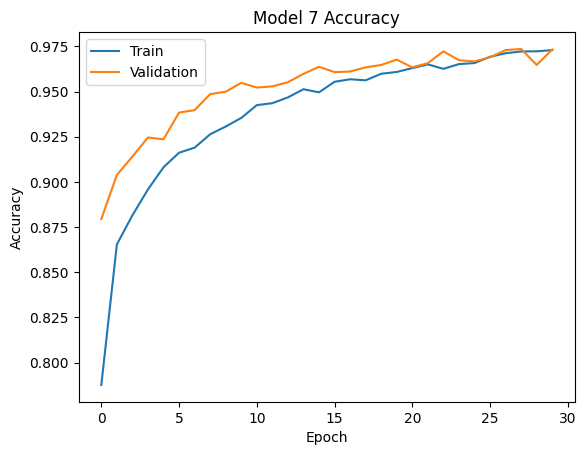

In [64]:
# Plot training & validation accuracy values

plt.plot(history7.history['accuracy'])
plt.plot(history7.history['val_accuracy'])
plt.title('Model 7 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

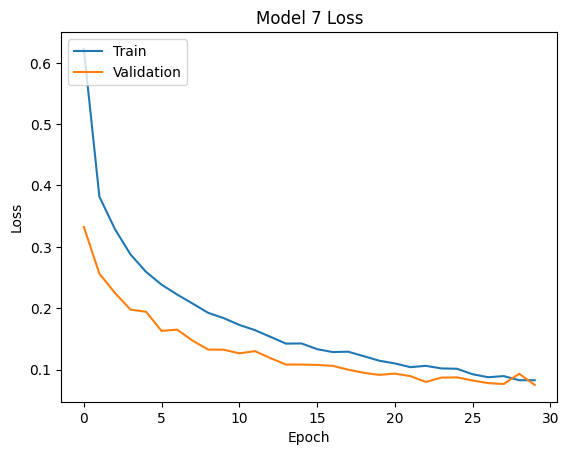

In [65]:
# Plotting train & validation loss

plt.plot(history7.history['loss'])
plt.plot(history7.history['val_loss'])
plt.title('Model 7 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [66]:
val_predictions7 = model7.predict(validation_ds7)
val_predicted_classes7 = np.argmax(val_predictions7, axis=1)
val_true_classes7 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds7])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes7, val_predicted_classes7, target_names=class_names))

380/380 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.98      0.97      1013
  meningioma       0.96      0.94      0.95       780
     notumor       0.99      0.98      0.99       802
   pituitary       0.98      0.99      0.98       442

    accuracy                           0.97      3037
   macro avg       0.97      0.97      0.97      3037
weighted avg       0.97      0.97      0.97      3037



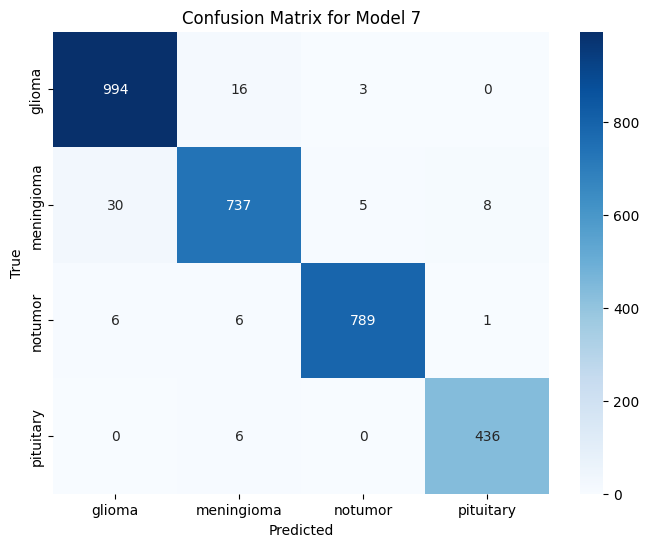

In [67]:
cm7 = confusion_matrix(val_true_classes7, val_predicted_classes7)
plt.figure(figsize=(8, 6))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 7')
plt.show()

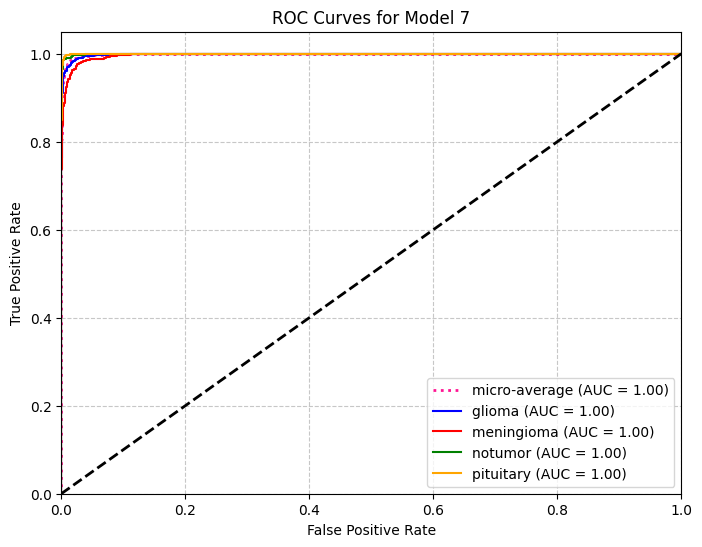

In [68]:
# Model 7 ROC/AUC

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 7
y_true = val_true_classes7
y_pred_proba = val_predictions7

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 7')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Final Model Comparison (Models 1-7)

Compares whichever of Models 1-7 have been trained in this session. You don't need to run all seven -- the table below includes however many are available, and notes which ones are missing.


In [69]:

all_model_specs = [
    ('Model 1', 'val_true_classes1', 'val_predicted_classes1', 'val_predictions1', 'training_time1', 'history1'),
    ('Model 2', 'val_true_classes2', 'val_predicted_classes2', 'val_predictions2', 'training_time2', 'history2'),
    ('Model 3', 'val_true_classes3', 'val_predicted_classes3', 'val_predictions3', 'training_time3', 'history3'),
    ('Model 4', 'val_true_classes4', 'val_predicted_classes4', 'val_predictions4', 'training_time4', 'history4'),
    ('Model 5', 'val_true_classes5', 'val_predicted_classes5', 'val_predictions5', 'training_time5', 'history5'),
    ('Model 6', 'val_true_classes6', 'val_predicted_classes6', 'val_predictions6', 'training_time6', 'history6'),
    ('Model 7', 'val_true_classes7', 'val_predicted_classes7', 'val_predictions7', 'training_time7', 'history7'),
]

models_data = []
for model_name, tc_name, pc_name, pr_name, tt_name, h_name in all_model_specs:
    if tc_name in globals():
        models_data.append({
            'Model Name': model_name,
            'val_true_classes': globals()[tc_name],
            'val_predicted_classes': globals()[pc_name],
            'val_predictions': globals()[pr_name],
            'training_time_min': globals()[tt_name],
            'history': globals()[h_name],
        })

if len(models_data) < len(all_model_specs):
    missing = [name for name, tc, *_ in all_model_specs if tc not in globals()]
    print(f"Note: comparing {len(models_data)} of {len(all_model_specs)} models "
          f"(not run in this session: {', '.join(missing)}).")

# Prepare lists to store results
results = []

for model in models_data:
    model_name = model['Model Name']
    y_true = model['val_true_classes']
    y_pred = model['val_predicted_classes']
    y_pred_proba = model['val_predictions']
    training_time_min_val = model['training_time_min'] # Retrieve in minutes
    model_history = model['history']

    # Calculate metrics
    val_accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    macro_auc = roc_auc_score(y_true, y_pred_proba, average='macro', multi_class='ovr')
    val_loss = min(model_history.history['val_loss'])

    results.append({
        'Model': model_name,
        'Validation Accuracy': val_accuracy,
        'Macro F1-Score': macro_f1,
        'Macro AUC': macro_auc,
        'Validation Loss': round(val_loss, 3),
        'Training Time (min)': round(training_time_min_val, 3)
    })

# Create DataFrame
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.set_index('Model')
# Display the DataFrame
display(comparison_df)


,Validation Accuracy,Macro F1-Score,Macro AUC,Validation Loss,Training Time (min)
Model,,,,,
Model 1,0.964439,0.966567,0.996401,0.130,17.382
Model 2,0.919328,0.927183,0.989784,0.203,9.360
Model 3,0.970365,0.973424,0.997138,0.109,19.331
Model 4,0.944682,0.947700,0.995301,0.149,36.224
Model 5,0.969707,0.971088,0.998220,0.091,24.428
Model 6,0.965756,0.966784,0.997427,0.105,85.647
Model 7,0.973329,0.974270,0.998828,0.075,58.020


## Combined ROC Comparison Across Models

/tmp/ipykernel_1047/1222896297.py:33: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
/tmp/ipykernel_1047/1222896297.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',


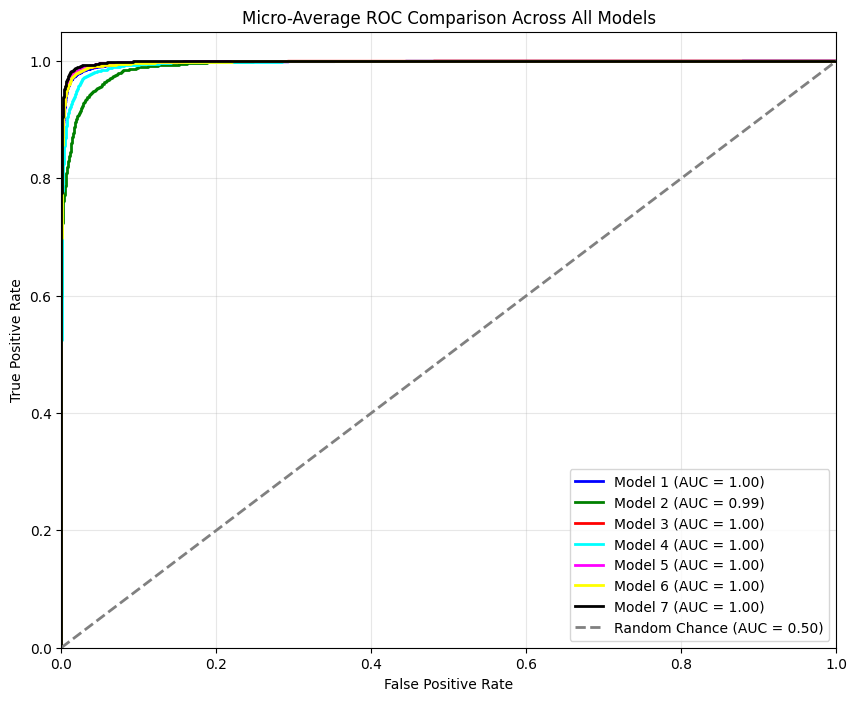

In [70]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# List of (model_name, val_true_classes, val_predictions) tuples for specified models
model_performance_data = [
    ('Model 1', val_true_classes1, val_predictions1),
    ('Model 2', val_true_classes2, val_predictions2),
    ('Model 3', val_true_classes3, val_predictions3),
    ('Model 4', val_true_classes4, val_predictions4),
    ('Model 5', val_true_classes5, val_predictions5),
    ('Model 6', val_true_classes6, val_predictions6),
    ('Model 7', val_true_classes7, val_predictions7)
]

plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black'] # Different colors for each model

for idx, (model_name, y_true, y_pred_proba) in enumerate(model_performance_data):
    # Binarize true labels for one-vs-rest ROC
    y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

    # Compute micro-average ROC curve and AUC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    # Plot the micro-average ROC curve for the current model
    plt.plot(fpr_micro, tpr_micro,
             label=f'{model_name} (AUC = {roc_auc_micro:.2f})',
             color=colors[idx], linewidth=2)

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
         label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Average ROC Comparison Across All Models')
plt.legend(loc='lower right', fontsize='medium') # Set font size for readability
plt.grid(True, alpha=0.3) # Add a light grid
plt.show()

### Weighted Multi-Criteria Ranking

Accuracy, Macro F1-Score, and Macro AUC end up tightly clustered across the top models, so picking a single "best" model based on just one of those numbers would be a pretty arbitrary decision — a tiny difference in accuracy could easily flip depending on which metric we looked at. Instead, we rank the models across **six criteria** and combine those ranks into one score:

- **Validation Accuracy** and **Macro F1-Score** — overall and class-balanced correctness.
- **Macro AUC** — ranking quality independent of the decision threshold.
- **Validation Loss** — a continuous measure of prediction confidence/calibration that accuracy alone throws away.
- **Stability** — how much validation accuracy jumps around epoch-to-epoch during training. A model that bounces around wildly but happens to land well on its last epoch is a less trustworthy choice than one that converges smoothly, even if their final numbers look similar.
- **Training Time** — a minor practical cost consideration, since a cheaper model is preferable when performance differences are marginal.

For each metric, every model gets a rank from 1 (best) to N (worst) among the models that were actually trained this session. We then take a **weighted average of those six ranks**:

| Metric | Weight |
|---|---|
| Accuracy | 1.0 |
| Macro F1-Score | 1.0 |
| Macro AUC | 1.0 |
| Validation Loss | 0.5 |
| Stability | 0.4 |
| Training Time | 0.15 |

accuracy, F1, and AUC are weighted equally since they capture complementary aspects of raw classification quality, and there's no strong reason to prioritize one over the others. Validation loss gets a moderate secondary weight — useful as a calibration signal, but shouldn't override the primary performance metrics. Stability gets a similar weight to loss, since training reliability matters in a medical application: a model with strong end-point numbers but erratic training behavior offers less confidence that it'll reproduce those numbers again. Training time is weighted lightly, mostly as a tiebreaker between otherwise closely-matched models rather than a dominant factor — this project prioritizes performance and process quality over raw compute cost.

**Lower weighted-average rank = better model.** Whichever model ends up with the lowest score is treated as the strongest overall candidate and gets selected for the final test-set evaluation.

In [71]:
# Stability metric: how much val_accuracy jumps epoch-to-epoch (lower = more stable)
# Using std of epoch-to-epoch differences, not raw std, so a normally-improving
# model isn't penalized just for trending upward over training.
def compute_stability(history):
    val_acc = history.history['val_accuracy']
    diffs = np.diff(val_acc)
    return np.std(diffs)

comparison_df['Stability_Score'] = [
    compute_stability(h) for h in
    [history1, history2, history3, history4, history5, history6, history7]
]

# 1. Create rank columns for each metric
comparison_df['Accuracy_Rank'] = comparison_df['Validation Accuracy'].rank(ascending=False)
comparison_df['F1_Rank'] = comparison_df['Macro F1-Score'].rank(ascending=False)
comparison_df['AUC_Rank'] = comparison_df['Macro AUC'].rank(ascending=False)
comparison_df['Loss_Rank'] = comparison_df['Validation Loss'].rank(ascending=True)
comparison_df['Time_Rank'] = comparison_df['Training Time (min)'].rank(ascending=True)
comparison_df['Stability_Rank'] = comparison_df['Stability_Score'].rank(ascending=True)

# 2. Weighted average rank
WEIGHTS = {
    'Accuracy_Rank': 1.0,
    'F1_Rank': 1.0,
    'AUC_Rank': 1.0,
    'Loss_Rank': 0.5,
    'Stability_Rank': 0.4,   # meaningful weight — instability is a real reliability concern
    'Time_Rank': 0.15
}
TOTAL_WEIGHT = sum(WEIGHTS.values())

comparison_df['Weighted_Avg_Rank'] = sum(
    comparison_df[col] * w for col, w in WEIGHTS.items()
) / TOTAL_WEIGHT

# 3. Sort by weighted average rank ascending (lower = better overall)
comparison_df = comparison_df.sort_values(by='Weighted_Avg_Rank', ascending=True)

print("\n--- Ranked Model Comparison ---")
display(comparison_df)

print(f"\nThe #1 model based on Weighted Average Rank is: {comparison_df.index[0]}")


--- Ranked Model Comparison ---


,Validation Accuracy,Macro F1-Score,Macro AUC,Validation Loss,Training Time (min),Stability_Score,Accuracy_Rank,F1_Rank,AUC_Rank,Loss_Rank,Time_Rank,Stability_Rank,Weighted_Avg_Rank
Model,,,,,,,,,,,,,
Model 7,0.973329,0.974270,0.998828,0.075,58.020,0.006358,1.0,1.0,1.0,1.0,6.0,1.0,1.185185
Model 5,0.969707,0.971088,0.998220,0.091,24.428,0.012463,3.0,3.0,2.0,2.0,4.0,3.0,2.666667
Model 3,0.970365,0.973424,0.997138,0.109,19.331,0.108138,2.0,2.0,4.0,4.0,3.0,6.0,3.172840
Model 6,0.965756,0.966784,0.997427,0.105,85.647,0.038151,4.0,4.0,3.0,3.0,7.0,4.0,3.740741
Model 1,0.964439,0.966567,0.996401,0.130,17.382,0.092102,5.0,5.0,5.0,5.0,2.0,5.0,4.888889
Model 4,0.944682,0.947700,0.995301,0.149,36.224,0.007406,6.0,6.0,6.0,6.0,5.0,2.0,5.567901
Model 2,0.919328,0.927183,0.989784,0.203,9.360,0.141671,7.0,7.0,7.0,7.0,1.0,7.0,6.777778



The #1 model based on Weighted Average Rank is: Model 7


## Final Test Set Evaluation — Best Model (Test Set Touched Once)

Requires the comparison cell above to have run (so `comparison_df` exists). Automatically selects and evaluates whichever model ranked best among the ones you trained in this session -- it only needs that one winning model to exist, not all 7.


In [72]:
# 1. Identify the best model from the comparison_df
best_model_name = comparison_df.index[0]
print(f"Selected Best Model (based on Validation Macro F1-Score): {best_model_name}\n")

# 2. Map each model name to (model variable name, its own test dataset variable name).
# Looked up dynamically via globals() so this only requires the WINNING model to
# actually exist -- it doesn't need every other model to have been trained too.
model_and_dataset_names = {
    "Model 1": ('model1', 'test_ds1'),
    "Model 2": ('model2', 'test_ds2'),
    "Model 3": ('model3', 'test_ds3'),
    "Model 4": ('model4', 'test_ds4'),
    "Model 5": ('model5', 'test_ds5'),
    "Model 6": ('model6', 'test_ds6'),
    "Model 7": ('model7', 'test_ds7'),
}

model_var_name, test_ds_var_name = model_and_dataset_names[best_model_name]
best_model = globals()[model_var_name]
best_test_dataset = globals()[test_ds_var_name]

# 3. Run prediction on the test set for the winning model
print(f"Evaluating {best_model_name} on the Test Set...\n")
test_predictions = best_model.predict(best_test_dataset)
test_predicted_classes = np.argmax(test_predictions, axis=1)

# Get true classes from the test dataset
test_true_classes = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in best_test_dataset])


Selected Best Model (based on Validation Macro F1-Score): Model 7

Evaluating Model 7 on the Test Set...

475/475 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step


In [73]:
print("Classification Report (Test Set):")
print(classification_report(test_true_classes, test_predicted_classes, target_names=class_names))

Classification Report (Test Set):
              precision    recall  f1-score   support

      glioma       0.98      0.97      0.98      1266
  meningioma       0.96      0.95      0.95       975
     notumor       0.98      0.98      0.98      1003
   pituitary       0.96      0.99      0.98       552

    accuracy                           0.97      3796
   macro avg       0.97      0.97      0.97      3796
weighted avg       0.97      0.97      0.97      3796



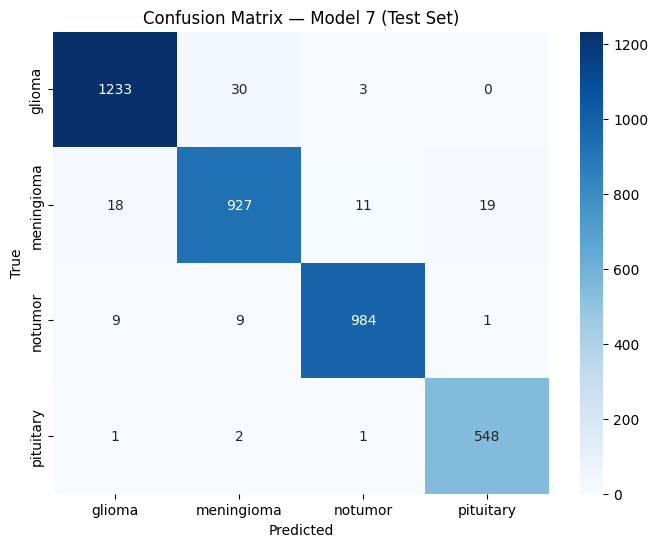

In [74]:
cm = confusion_matrix(test_true_classes, test_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_model_name} (Test Set)')
plt.show()

/tmp/ipykernel_1047/1207613199.py:24: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
/tmp/ipykernel_1047/1207613199.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',


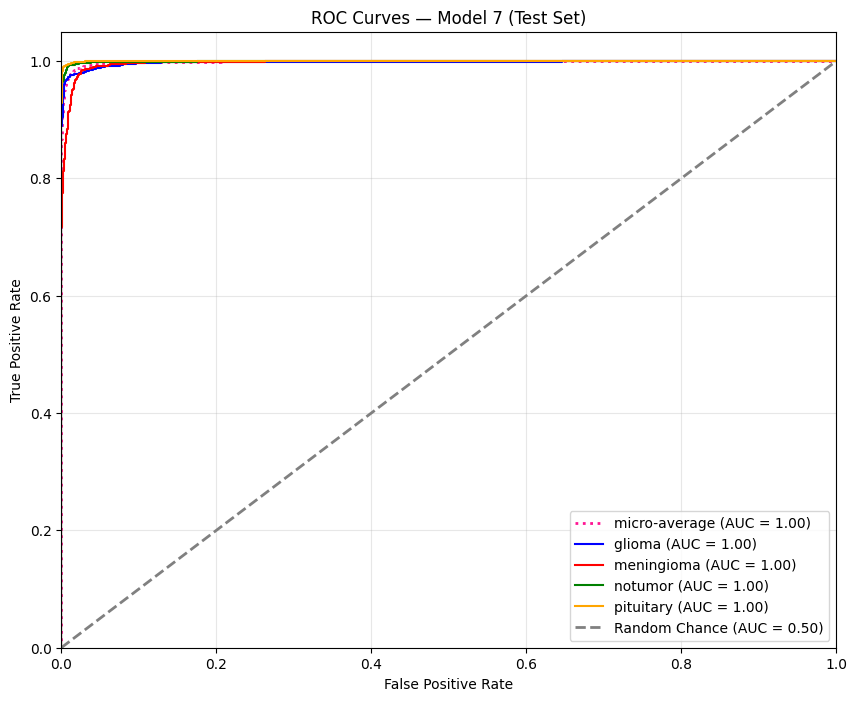

In [75]:
y_true_binarized_test = label_binarize(test_true_classes, classes=range(NUM_CLASSES))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_test[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized_test.ravel(), test_predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

colors_roc = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors_roc):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', linestyle='--',
         label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves — {best_model_name} (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

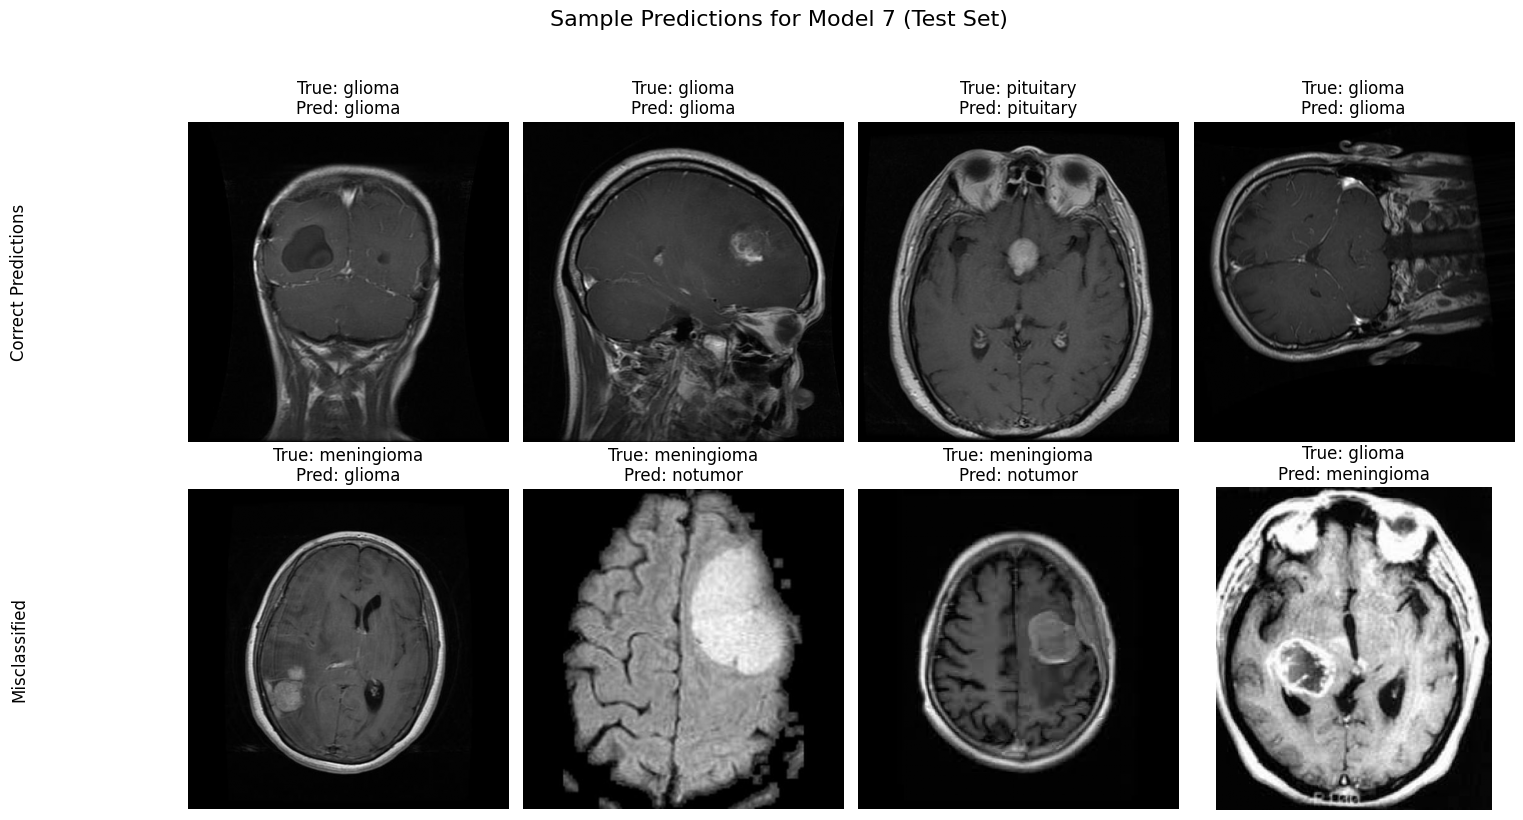

In [76]:
test_paths = X_test_paths_main

test_results_for_display = []
for i in range(len(test_paths)):
    test_results_for_display.append({
        'path': test_paths[i],
        'true_label_idx': test_true_classes[i],
        'predicted_label_idx': test_predicted_classes[i]
    })

correct_examples = []
misclassified_examples = []

for item in test_results_for_display:
    if item['true_label_idx'] == item['predicted_label_idx']:
        correct_examples.append(item)
    else:
        misclassified_examples.append(item)

num_to_display = 4
selected_correct = correct_examples[:num_to_display]
selected_misclassified = misclassified_examples[:num_to_display]

fig, axes = plt.subplots(2, num_to_display, figsize=(15, 8))
fig.suptitle(f"Sample Predictions for {best_model_name} (Test Set)", fontsize=16, y=1.02)

for i, ax in enumerate(axes[0]):
    if i < len(selected_correct):
        item = selected_correct[i]
        try:
            img = Image.open(item['path']).convert('L')
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off')

for i, ax in enumerate(axes[1]):
    if i < len(selected_misclassified):
        item = selected_misclassified[i]
        try:
            img = Image.open(item['path']).convert('L')
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off')

axes[0, 0].text(-0.5, 0.5, "Correct Predictions", rotation=90, va='center', ha='right', transform=axes[0, 0].transAxes, fontsize=12)
axes[1, 0].text(-0.5, 0.5, "Misclassified", rotation=90, va='center', ha='right', transform=axes[1, 0].transAxes, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Model 8: Balanced Dataset (undersampling) without Class Weights

For this model, we will address the class imbalance by undersampling the larger classes to match the number of images in the smallest class (pituitary). This creates a balanced dataset, and therefore, we will train the model without explicit class weights. The double augmentation for pituitary images will also be removed for this model, by using a new `make_dataset` function specific to Model 8.

**Run the cells below (and the balanced split near the top of the notebook) if you want to train Model 8.** This section is fully self-contained -- it doesn't depend on any of Models 1-7's cells.


In [77]:
def augment_model8(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

In [78]:
TARGET_SIZE = (256, 256)
NUM_CLASSES = 4
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, TARGET_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

# New make_dataset function for Model 8 without pituitary augmentation
def make_dataset_for_model8(paths, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment_model8, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [79]:
print(f"Number of pituitary images: {len(classes_data['pituitary'])}")
print(f"Total images in balanced dataset: {len(balanced_paths)}")
print(f"Distribution of classes in balanced dataset: {Counter(balanced_labels)}")


train_ds8 = make_dataset_for_model8(X_train_paths_balanced, y_train_balanced, shuffle=True, augment_data=True)
validation_ds8 = make_dataset_for_model8(X_val_paths_balanced, y_val_balanced, shuffle=False)
test_ds8 = make_dataset_for_model8(X_test_paths_balanced, y_test_balanced, shuffle=False)

print(f"Balanced Training set size: {len(X_train_paths_balanced)}")
print(f"Balanced Validation set size: {len(X_val_paths_balanced)}")
print(f"Balanced Test set size: {len(X_test_paths_balanced)}")

Number of pituitary images: 2761
Total images in balanced dataset: 11044
Distribution of classes in balanced dataset: Counter({np.int64(0): 2761, np.int64(1): 2761, np.int64(2): 2761, np.int64(3): 2761})
Balanced Training set size: 7068
Balanced Validation set size: 1767
Balanced Test set size: 2209


In [80]:
model8 = Sequential()

model8.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,1)))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model8.add(BatchNormalization())
model8.add(MaxPooling2D((2,2)))

model8.add(Flatten())
model8.add(Dense(256, activation='relu'))
model8.add(Dropout(0.5))
model8.add(Dense(NUM_CLASSES, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
early_stop_model8 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model8.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time8 = time.time()
history8 = model8.fit(train_ds8, epochs=30, validation_data=validation_ds8, callbacks=[early_stop_model8])
end_time8 = time.time()
training_time8 = (end_time8 - start_time8) / 60  # Convert to minutes
print(f"Model 8 training time: {training_time8:.3f} minutes")

Epoch 1/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 47s 176ms/step - accuracy: 0.5504 - loss: 1.4474 - val_accuracy: 0.3662 - val_loss: 5.5180
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.6497 - loss: 0.8527 - val_accuracy: 0.4663 - val_loss: 1.6415
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.6834 - loss: 0.7599 - val_accuracy: 0.7753 - val_loss: 0.5882
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.7179 - loss: 0.6940 - val_accuracy: 0.8149 - val_loss: 0.4869
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - accuracy: 0.7383 - loss: 0.6149 - val_accuracy: 0.8274 - val_loss: 0.4554
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.7721 - loss: 0.5553 - val_accuracy: 0.8546 - val_loss: 0.4203
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.7968 - loss: 0.5056 - val_accuracy: 0.8625 - val_loss: 0.3606
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.8230 - loss: 0

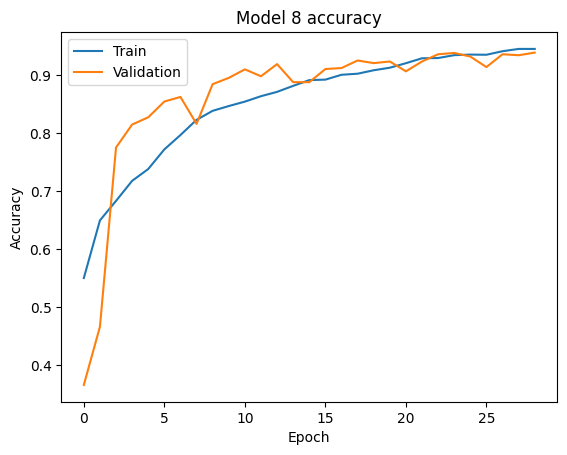

In [82]:
# Plot training & validation accuracy values
plt.plot(history8.history['accuracy'])
plt.plot(history8.history['val_accuracy'])
plt.title('Model 8 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

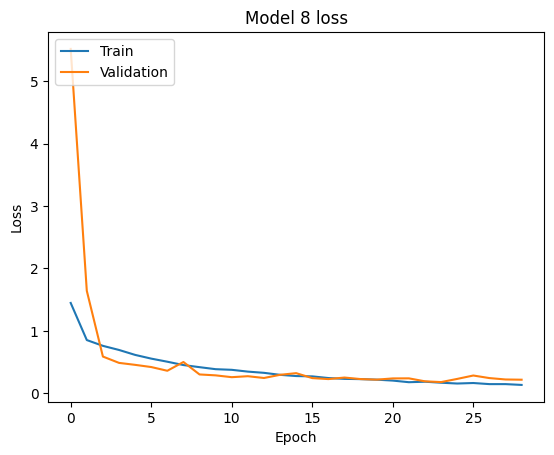

In [83]:
# Plotting train & validation loss
plt.plot(history8.history['loss'])
plt.plot(history8.history['val_loss'])
plt.title('Model 8 loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [84]:
val_predictions8 = model8.predict(validation_ds8)
val_predicted_classes8 = np.argmax(val_predictions8, axis=1)
val_true_classes8 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in validation_ds8])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(classification_report(val_true_classes8, val_predicted_classes8, target_names=class_names))

56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step
              precision    recall  f1-score   support

      glioma       0.95      0.87      0.91       442
  meningioma       0.89      0.93      0.91       442
     notumor       0.94      0.96      0.95       441
   pituitary       0.98      0.99      0.99       442

    accuracy                           0.94      1767
   macro avg       0.94      0.94      0.94      1767
weighted avg       0.94      0.94      0.94      1767



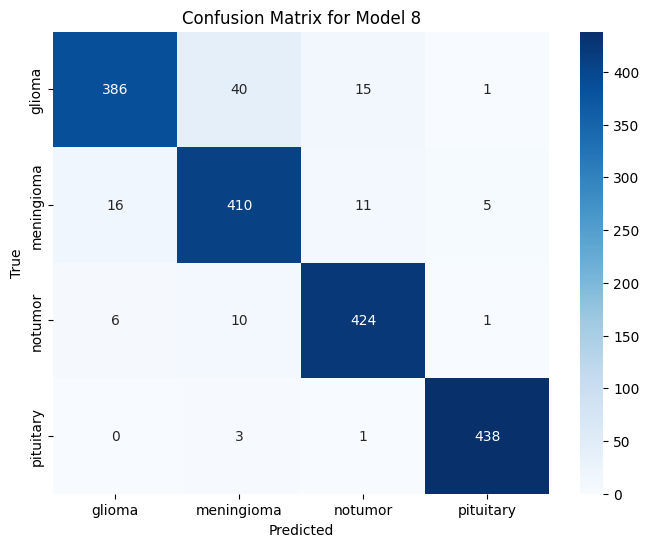

In [85]:
cm8 = confusion_matrix(val_true_classes8, val_predicted_classes8)
plt.figure(figsize=(8, 6))
sns.heatmap(cm8, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 8')
plt.show()

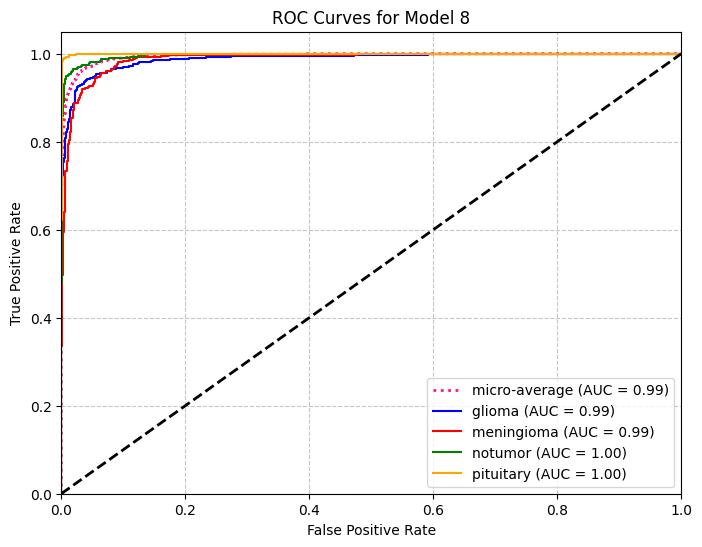

In [86]:
# Model 8 ROC/AUC


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 8
y_true = val_true_classes8
y_pred_proba = val_predictions8

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 8')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Model 8 - Test Set Evaluation

In [87]:
test_predictions8 = model8.predict(test_ds8)
test_predicted_classes8 = np.argmax(test_predictions8, axis=1)

# Get true classes from the test dataset
# The datasets are not shuffled during creation for test sets, so order should match paths.
test_true_classes8 = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds8])

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Classification Report (Test Set for Model 8):")
print(classification_report(test_true_classes8, test_predicted_classes8, target_names=class_names))

70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step
Classification Report (Test Set for Model 8):
              precision    recall  f1-score   support

      glioma       0.94      0.91      0.93       552
  meningioma       0.90      0.90      0.90       552
     notumor       0.95      0.97      0.96       553
   pituitary       0.98      0.99      0.98       552

    accuracy                           0.94      2209
   macro avg       0.94      0.94      0.94      2209
weighted avg       0.94      0.94      0.94      2209



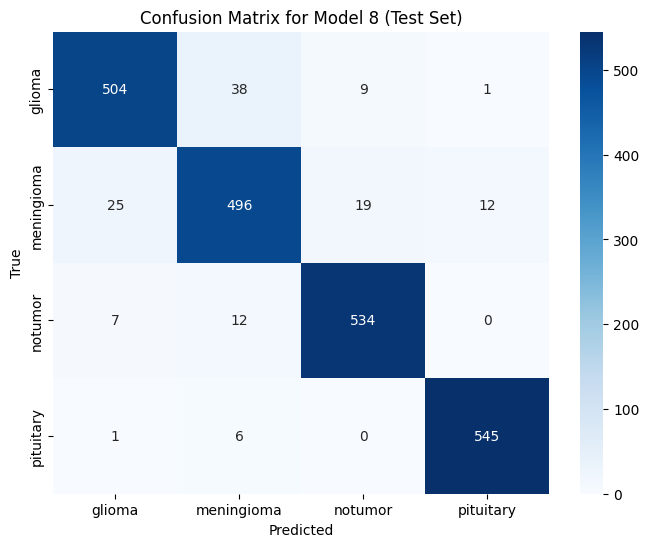

In [88]:
cm8_test = confusion_matrix(test_true_classes8, test_predicted_classes8)
plt.figure(figsize=(8, 6))
sns.heatmap(cm8_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Model 8 (Test Set)')
plt.show()

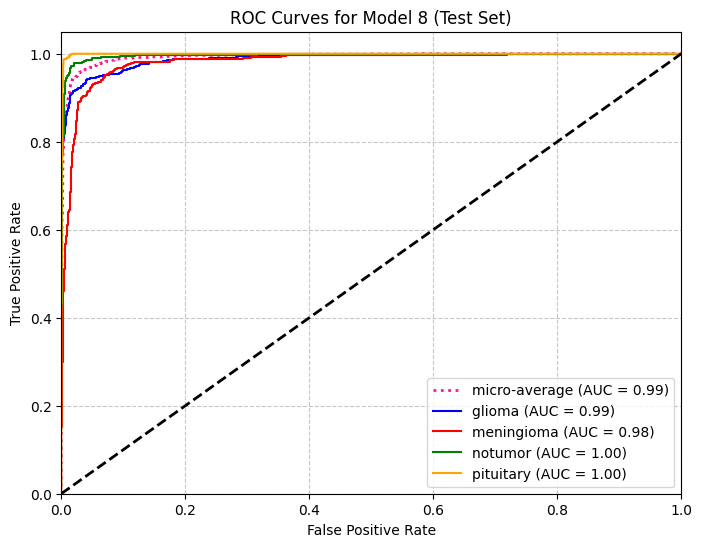

In [89]:
# Model 8 ROC/AUC (Test Set)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

# True labels and prediction probabilities for Model 8
y_true = test_true_classes8
y_pred_proba = test_predictions8

# Binarize true labels for one-vs-rest ROC
y_true_binarized = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=2)

# Plot individual class ROC curves
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model 8 (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

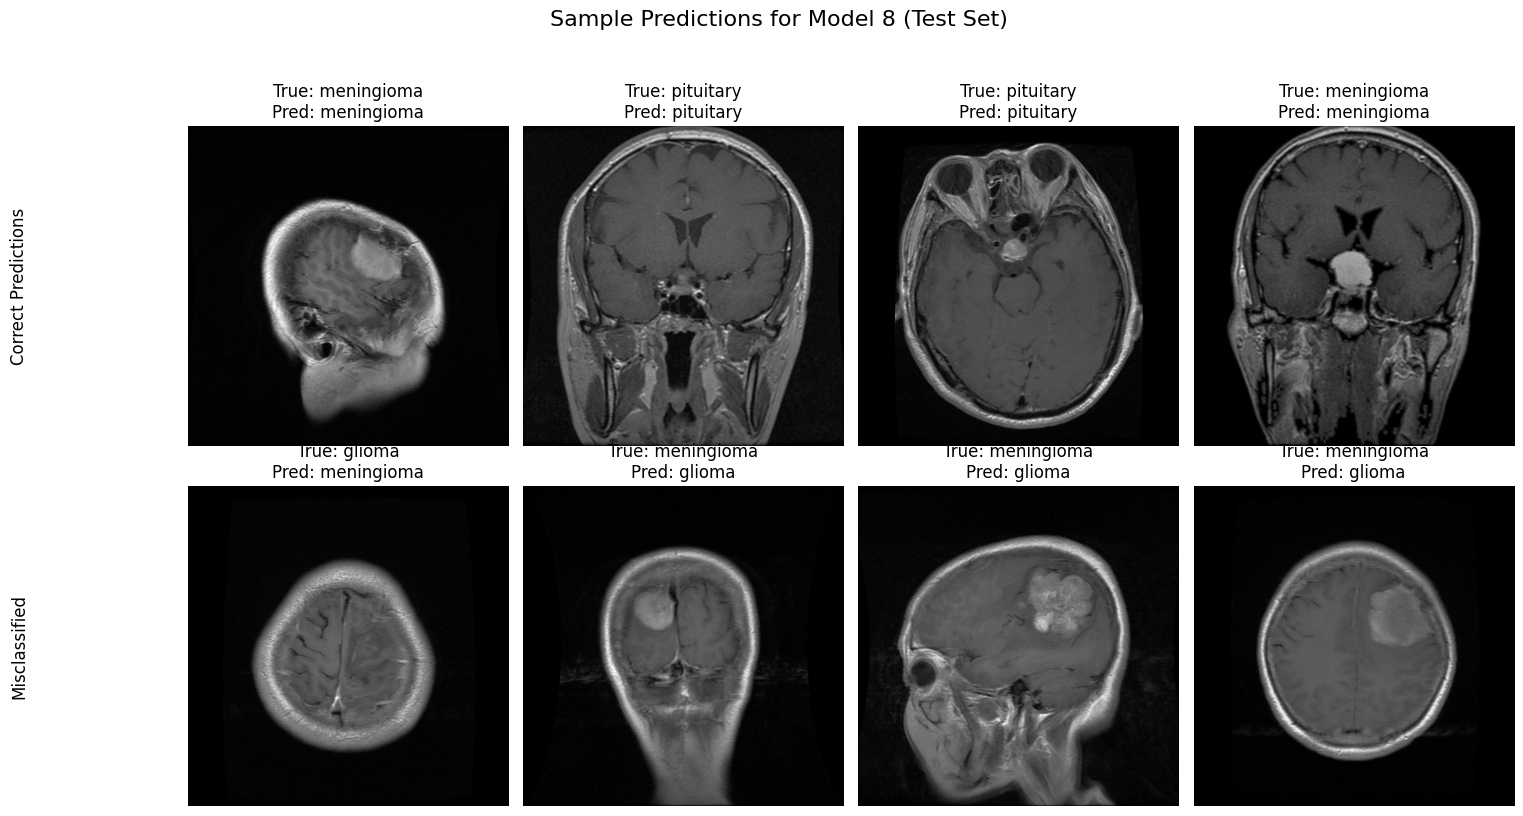

In [90]:
# Build a grid of sample images (correctly and misclassified) for Model 8

# Reusing X_test_paths_balanced which was defined earlier for Model 8's test split
test_paths_model8 = X_test_paths_balanced

# Create a list of (path, true_label, predicted_label) for analysis
test_results_for_display_model8 = []
for i in range(len(test_paths_model8)):
    test_results_for_display_model8.append({
        'path': test_paths_model8[i],
        'true_label_idx': test_true_classes8[i],
        'predicted_label_idx': test_predicted_classes8[i]
    })

correct_examples_model8 = []
misclassified_examples_model8 = []

for item in test_results_for_display_model8:
    if item['true_label_idx'] == item['predicted_label_idx']:
        correct_examples_model8.append(item)
    else:
        misclassified_examples_model8.append(item)

# Select up to 4 correct and 4 misclassified examples
num_to_display = 4
selected_correct_model8 = correct_examples_model8[:num_to_display]
selected_misclassified_model8 = misclassified_examples_model8[:num_to_display]

fig, axes = plt.subplots(2, num_to_display, figsize=(15, 8))
fig.suptitle(f"Sample Predictions for Model 8 (Test Set)", fontsize=16, y=1.02)

# Display Correct Predictions
for i, ax in enumerate(axes[0]):
    if i < len(selected_correct_model8):
        item = selected_correct_model8[i]
        try:
            img = Image.open(item['path']).convert('L')
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots

# Display Misclassified Predictions
for i, ax in enumerate(axes[1]):
    if i < len(selected_misclassified_model8):
        item = selected_misclassified_model8[i]
        try:
            img = Image.open(item['path']).convert('L')
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {class_names[item['true_label_idx']]}\nPred: {class_names[item['predicted_label_idx']]}")
            ax.axis('off')
        except Exception as e:
            ax.set_title(f"Load Error: {e}")
            ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots

axes[0, 0].text(-0.5, 0.5, "Correct Predictions", rotation=90, va='center', ha='right', transform=axes[0, 0].transAxes, fontsize=12)
axes[1, 0].text(-0.5, 0.5, "Misclassified", rotation=90, va='center', ha='right', transform=axes[1, 0].transAxes, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Summary

This notebook set out to build a model that classifies brain MRI scans into four categories — glioma, meningioma, pituitary tumor, and no tumor — and the process surfaced a few recurring problems that shaped almost every decision made along the way.

**The data was the main challenge, more than the modeling.** Three separate Kaggle datasets were merged to get enough images, but that merge came with real costs:
- **Duplication cut the usable dataset roughly in half.** Combining three sources meant the same scan often appeared more than once — perceptual hashing (pHash) was used to detect and remove these, taking the aggregated ~32,000 images down to under 19,000 unique ones.
- **The remaining data was still imbalanced.** Even after deduplication, pituitary tumor images were noticeably underrepresented compared to the other three classes — the class-distribution chart earlier in this notebook made that gap clear. This is why class weighting (and, for Model 8, undersampling as an alternative) was necessary rather than optional.
- **Merging sources introduced confounds beyond just duplicates.** The color-mode analysis showed that whether an image was color or grayscale correlated with both its class *and* which of the three source datasets it came from — meaning some of what looks like "class signal" in the raw files is really just "which dataset this came from." Grayscale conversion in preprocessing neutralizes the color part of that risk, but it's a reminder that aggregating heterogeneous public sources brings baggage beyond simple sample duplication.


**Bottom line:** the results in this notebook likely sit close to the ceiling achievable given the data available — a class-imbalanced, deduplication-reduced aggregation of three heterogeneous public sources — rather than a limitation of the architectures or hyperparameters tried. Improving on this further would mean addressing the underlying data (more images, ideally from a single consistently-labeled source) more than further tuning the models themselves.